# Análise Exploratória dos Dados de Prefeitos (2k-200k habitantes)

Este notebook apresenta uma análise exploratória do arquivo `dados_unificados_prefeitos_200k.csv`, que consolida as informações de resultados eleitorais, valores de emendas PIX e indicadores socioeconômicos dos municípios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm # estimação de modelos
from scipy import stats # estatística chi2
from statsmodels.iolib.summary2 import summary_col # comparação entre modelos
from scipy.stats import gaussian_kde # inserção de KDEs em gráficos
from matplotlib.gridspec import GridSpec # plotagem de gráficos separados
import time # definição do intervalo de tempo entre gráficos com animação
import imageio # para geração de figura GIF
from tqdm import tqdm # adiciona um indicador de progresso do código

In [30]:
sns.set(style='whitegrid')
pd.options.display.float_format = '{:.2f}'.format

path = '../data/dados_unificados_prefeitos_200k.csv'
df = pd.read_csv(path)

In [3]:
df.head()

,municipio,sigla_municipio,prefeito_eleito_2024,sigla_partido_prefeito_eleito,porcentagem_votos_validos_2024,emendas_pix_per_capita_partido_prefeito_eleito,idhm_2010,alfabetizacao_2010,pib_per_capita_2021,densidade_demografica_2010
0,ABADIA DE GOIAS - GO,GO,WANDER SARAIVA,PP,1.00,18716.02,0.71,92.19,18491.22,133.40
1,ABADIA DOS DOURADOS - MG,MG,CIRO,PSD,0.58,3188.78,0.69,90.88,28184.63,7.13
2,ABADIANIA - GO,GO,DR ITAMAR,PP,0.62,3481.89,0.69,89.16,25842.85,16.51
3,ABAETE - MG,MG,IVANIR,MDB,0.49,1764.06,0.70,91.28,23869.42,12.48
4,ABAETETUBA - PA,PA,FRANCINETI CARVALHO,MDB,0.42,2528.61,0.63,86.29,12322.94,98.23


## Visão Geral

A primeira etapa consiste em verificar o formato da base e o tipo das variáveis.

### Filtragem de casos sem emendas ou com votação unânime e partidos com menos de 10 candidatos
As análises a seguir desconsideram municípios que receberam soma zero de Emendas PIX e onde apenas um candidato concorreu (100% dos votos válidos).

In [4]:
# Contar e printar 0s da coluna 'emendas_pix_per_capita_partido_prefeito_eleito'
# zero_count = (df['emendas_pix_per_capita_partido_prefeito_eleito'] == 0).sum()
# print(f'Número de zeros na coluna "emendas_pix_per_capita_partido_prefeito_eleito": {zero_count}')

# Contar e printar 1s da coluna 'porcentagem_votos_validos_2024'
one_count = (df['porcentagem_votos_validos_2024'] == 1).sum()
print(f'Número de uns na coluna "porcentagem_votos_validos_2024": {one_count}')
    

Número de uns na coluna "porcentagem_votos_validos_2024": 264


In [5]:
# Remover 0s da coluna 'emendas_pix_per_capita_partido_prefeito_eleito'
# df = df[df['emendas_pix_per_capita_partido_prefeito_eleito'] > 0]

# Remover 1s da coluna 'porcentual_votos_partido_prefeito_eleito'
df = df[df['porcentagem_votos_validos_2024'] < 1]

# Contar e printar onde a soma de municipios de determinado partido é menor que 10
parties = df['sigla_partido_prefeito_eleito'].value_counts()
low_count_parties = parties[parties < 10]
print("Partidos com menos de 10 municípios:")
for party, count in low_count_parties.items():
    print(f'{party}: {count} municípios')
    
# Remover partidos com menos de 10 municípios
df = df[df['sigla_partido_prefeito_eleito'].isin(parties[parties >= 10].index)]

# Remover linhas com valores NaN
df = df.dropna(subset=['emendas_pix_per_capita_partido_prefeito_eleito', 'porcentagem_votos_validos_2024', 'sigla_partido_prefeito_eleito'])

# Remover linhas com valores NaN
df.shape, df.dtypes

Partidos com menos de 10 municípios:
REDE: 3 municípios
PMB: 2 municípios
DC: 2 municípios
AGIR: 2 municípios


((4935, 10),
 municipio                                          object
 sigla_municipio                                    object
 prefeito_eleito_2024                               object
 sigla_partido_prefeito_eleito                      object
 porcentagem_votos_validos_2024                    float64
 emendas_pix_per_capita_partido_prefeito_eleito    float64
 idhm_2010                                         float64
 alfabetizacao_2010                                float64
 pib_per_capita_2021                               float64
 densidade_demografica_2010                        float64
 dtype: object)

In [6]:
# Remover valores extremos da coluna 'emendas_pix_per_capita_partido_prefeito_eleito'
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df = remove_outliers(df, 'emendas_pix_per_capita_partido_prefeito_eleito')

In [7]:
# Atribuição de categorias para as variáveis 'prefeito_eleito_2024', 'sigla_partido_prefeito_eleito', 'municipio', and 'sigla_municipio'
df['prefeito_eleito_2024'] = df['prefeito_eleito_2024'].astype('category')
df['sigla_partido_prefeito_eleito'] = df['sigla_partido_prefeito_eleito'].astype('category')
df['municipio'] = df['municipio'].astype('category')
df['sigla_municipio'] = df['sigla_municipio'].astype('category')

In [8]:
df.describe().round(2)

,porcentagem_votos_validos_2024,emendas_pix_per_capita_partido_prefeito_eleito,idhm_2010,alfabetizacao_2010,pib_per_capita_2021,densidade_demografica_2010
count,4385.00,4385.00,4365.00,4365.00,4385.00,4385.00
mean,0.59,2826.77,0.66,83.80,34091.44,75.51
std,0.12,4490.44,0.07,9.78,40248.22,325.96
min,0.23,0.00,0.42,55.60,5698.89,0.15
25%,0.51,0.00,0.60,75.61,13386.68,12.04
50%,0.57,0.00,0.66,86.97,23980.20,25.11
75%,0.66,4252.06,0.72,91.92,40983.79,55.14
max,0.99,18368.55,0.86,98.96,919488.03,10718.67


## Estudo sobre o desbalanceamento dos dados por partido

In [9]:
# Group by 'sigla_partido_prefeito_eleito'
df.groupby('sigla_partido_prefeito_eleito')['municipio'].count().reset_index()

desempenho_medio = df.groupby('sigla_partido_prefeito_eleito')['porcentagem_votos_validos_2024'].mean().reset_index()
desempenho_medio

C:\Users\bruno\AppData\Local\Temp\ipykernel_1016\1625412646.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sigla_partido_prefeito_eleito')['municipio'].count().reset_index()
C:\Users\bruno\AppData\Local\Temp\ipykernel_1016\1625412646.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desempenho_medio = df.groupby('sigla_partido_prefeito_eleito')['porcentagem_votos_validos_2024'].mean().reset_index()


,sigla_partido_prefeito_eleito,porcentagem_votos_validos_2024
0,AVANTE,0.58
1,CIDADANIA,0.64
2,MDB,0.59
3,MOBILIZA,0.61
4,NOVO,0.54
5,PC do B,0.62
6,PDT,0.58
7,PL,0.57
8,PODE,0.56
9,PP,0.58


## Desempenho médio eleição por partido

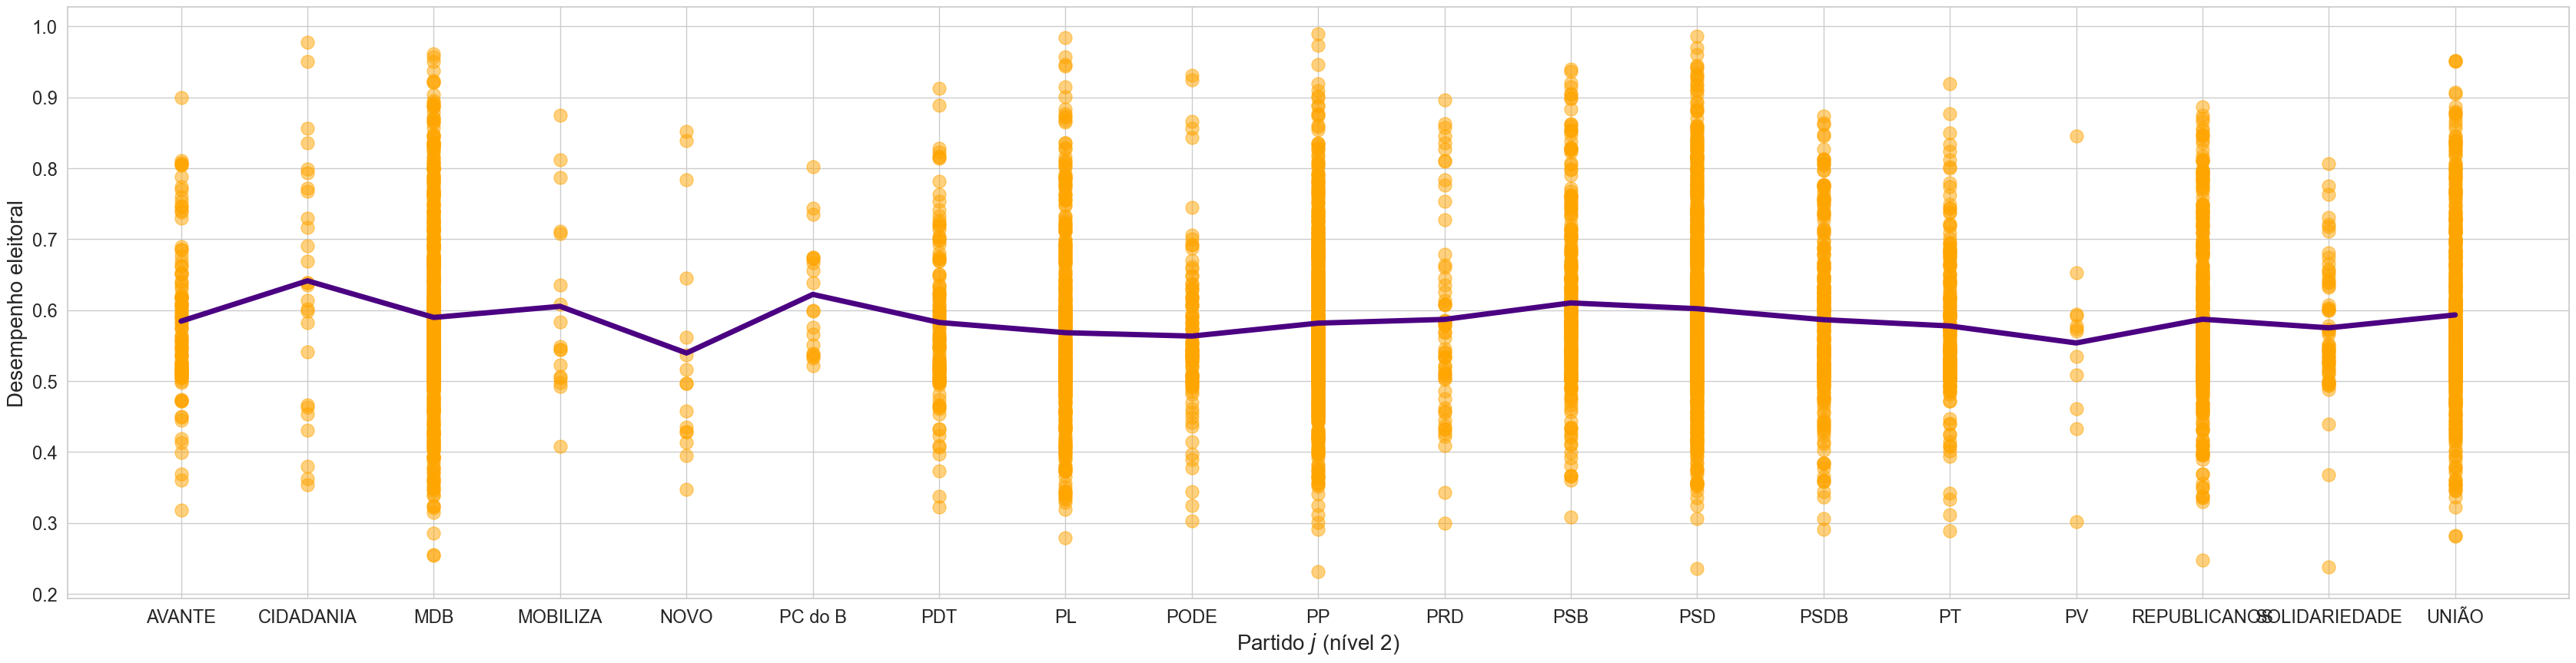

In [28]:
plt.figure(figsize=(42,10))
plt.plot(desempenho_medio['sigla_partido_prefeito_eleito'], desempenho_medio['porcentagem_votos_validos_2024'],
         linewidth=5, color='indigo')
plt.scatter(df['sigla_partido_prefeito_eleito'], df['porcentagem_votos_validos_2024'],
            alpha=0.5, color='orange', s = 150)
plt.xlabel('Partido $j$ (nível 2)', fontsize=20)
plt.ylabel('Desempenho eleitoral', fontsize=20)
plt.xticks(desempenho_medio.sigla_partido_prefeito_eleito, fontsize=17)
plt.yticks(fontsize=17)
plt.show()

## Boxplot da variável dependente ('desempenho')

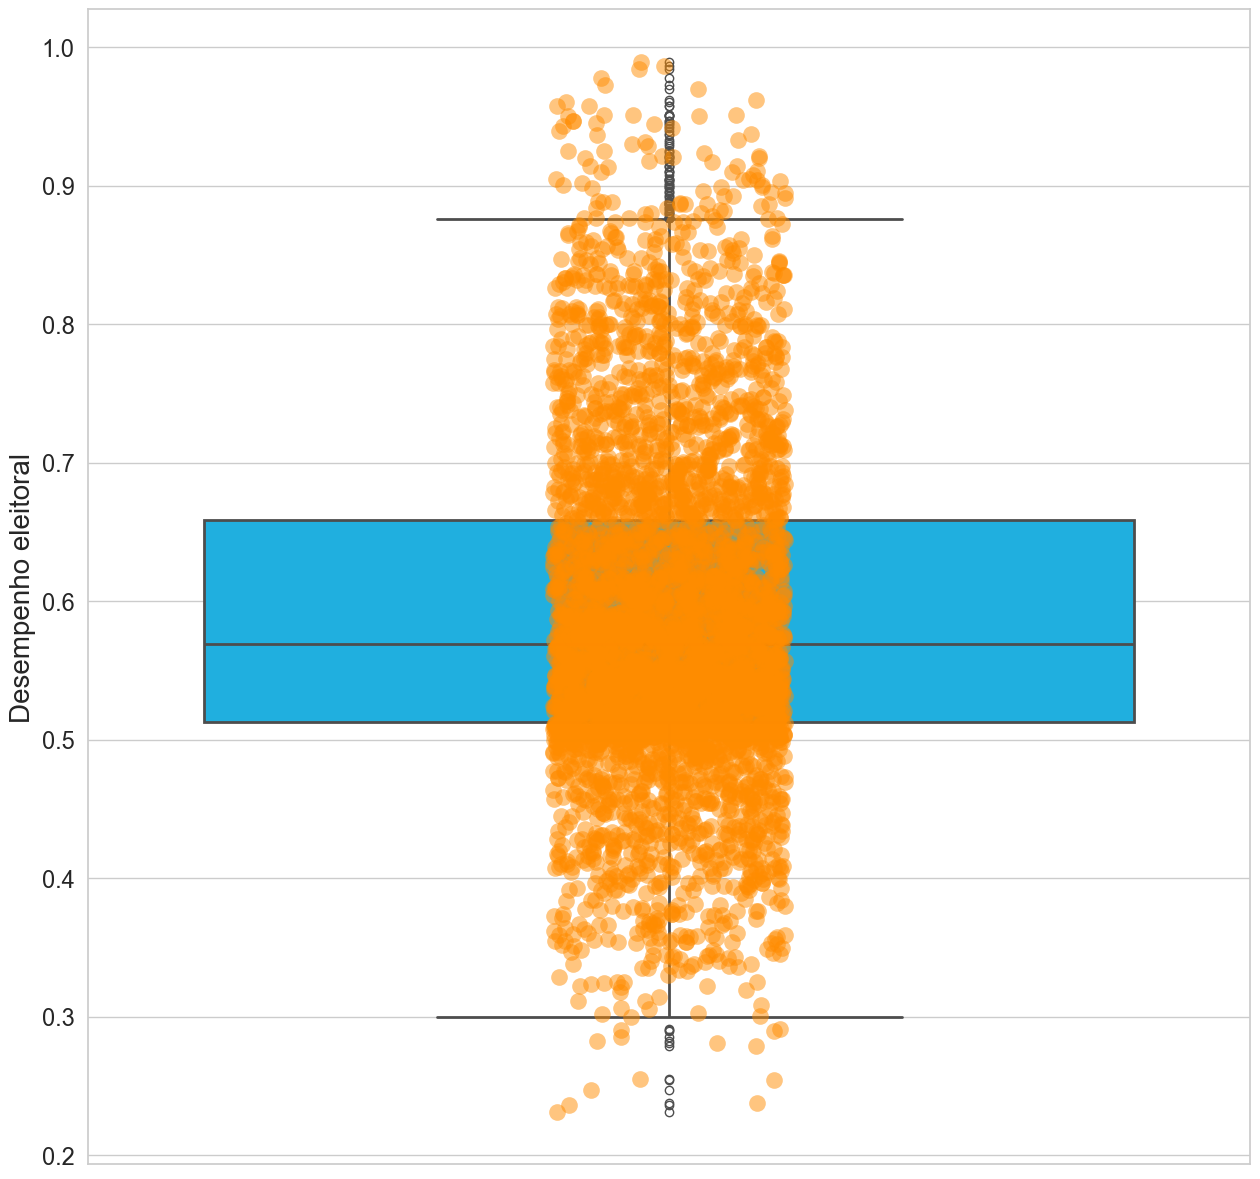

In [11]:
plt.figure(figsize=(15,15))
sns.boxplot(data=df, y='porcentagem_votos_validos_2024',
            linewidth=2, orient='v', color='deepskyblue')
sns.stripplot(data=df, y='porcentagem_votos_validos_2024',
              color='darkorange', jitter=0.1, size=12, alpha=0.5)
plt.ylabel('Desempenho eleitoral', fontsize=20)
plt.yticks(fontsize=17)
plt.show()

## Kernel density estimation (KDE) - função densidade de probabilidade

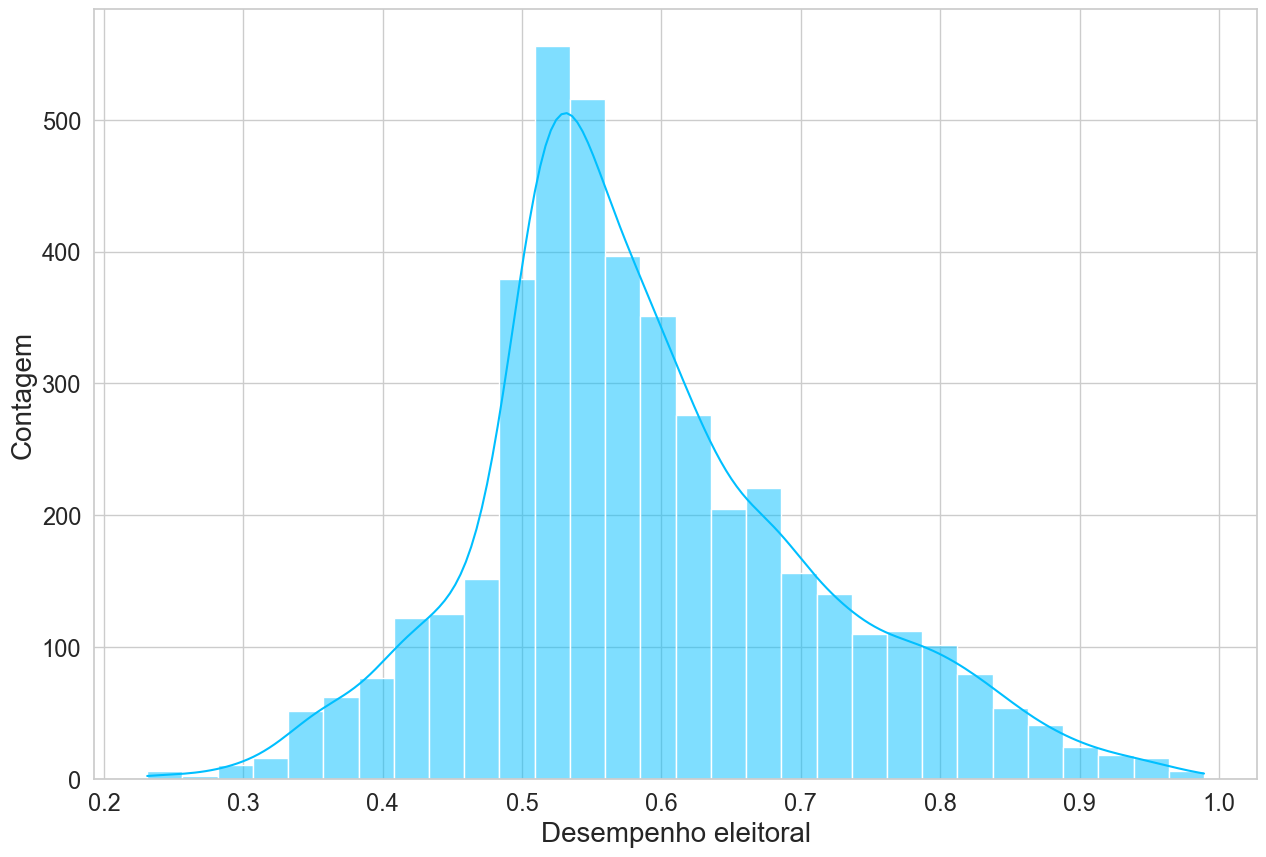

In [12]:
#da variável dependente ('porcentagem_votos_validos_2024'), com histograma
plt.figure(figsize=(15,10))
sns.histplot(data=df['porcentagem_votos_validos_2024'], kde=True,
             bins=30, color='deepskyblue')
plt.xlabel('Desempenho eleitoral', fontsize=20)
plt.ylabel('Contagem', fontsize=20)
plt.tick_params(axis='y', labelsize=17)
plt.tick_params(axis='x', labelsize=17)
plt.show()

## Boxplot da variável dependente ('desempenho') por sigla_partido_prefeito_eleito

C:\Users\bruno\AppData\Local\Temp\ipykernel_1016\1733418731.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sigla_partido_prefeito_eleito', y='porcentagem_votos_validos_2024',
C:\Users\bruno\AppData\Local\Temp\ipykernel_1016\1733418731.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='sigla_partido_prefeito_eleito', y='porcentagem_votos_validos_2024',


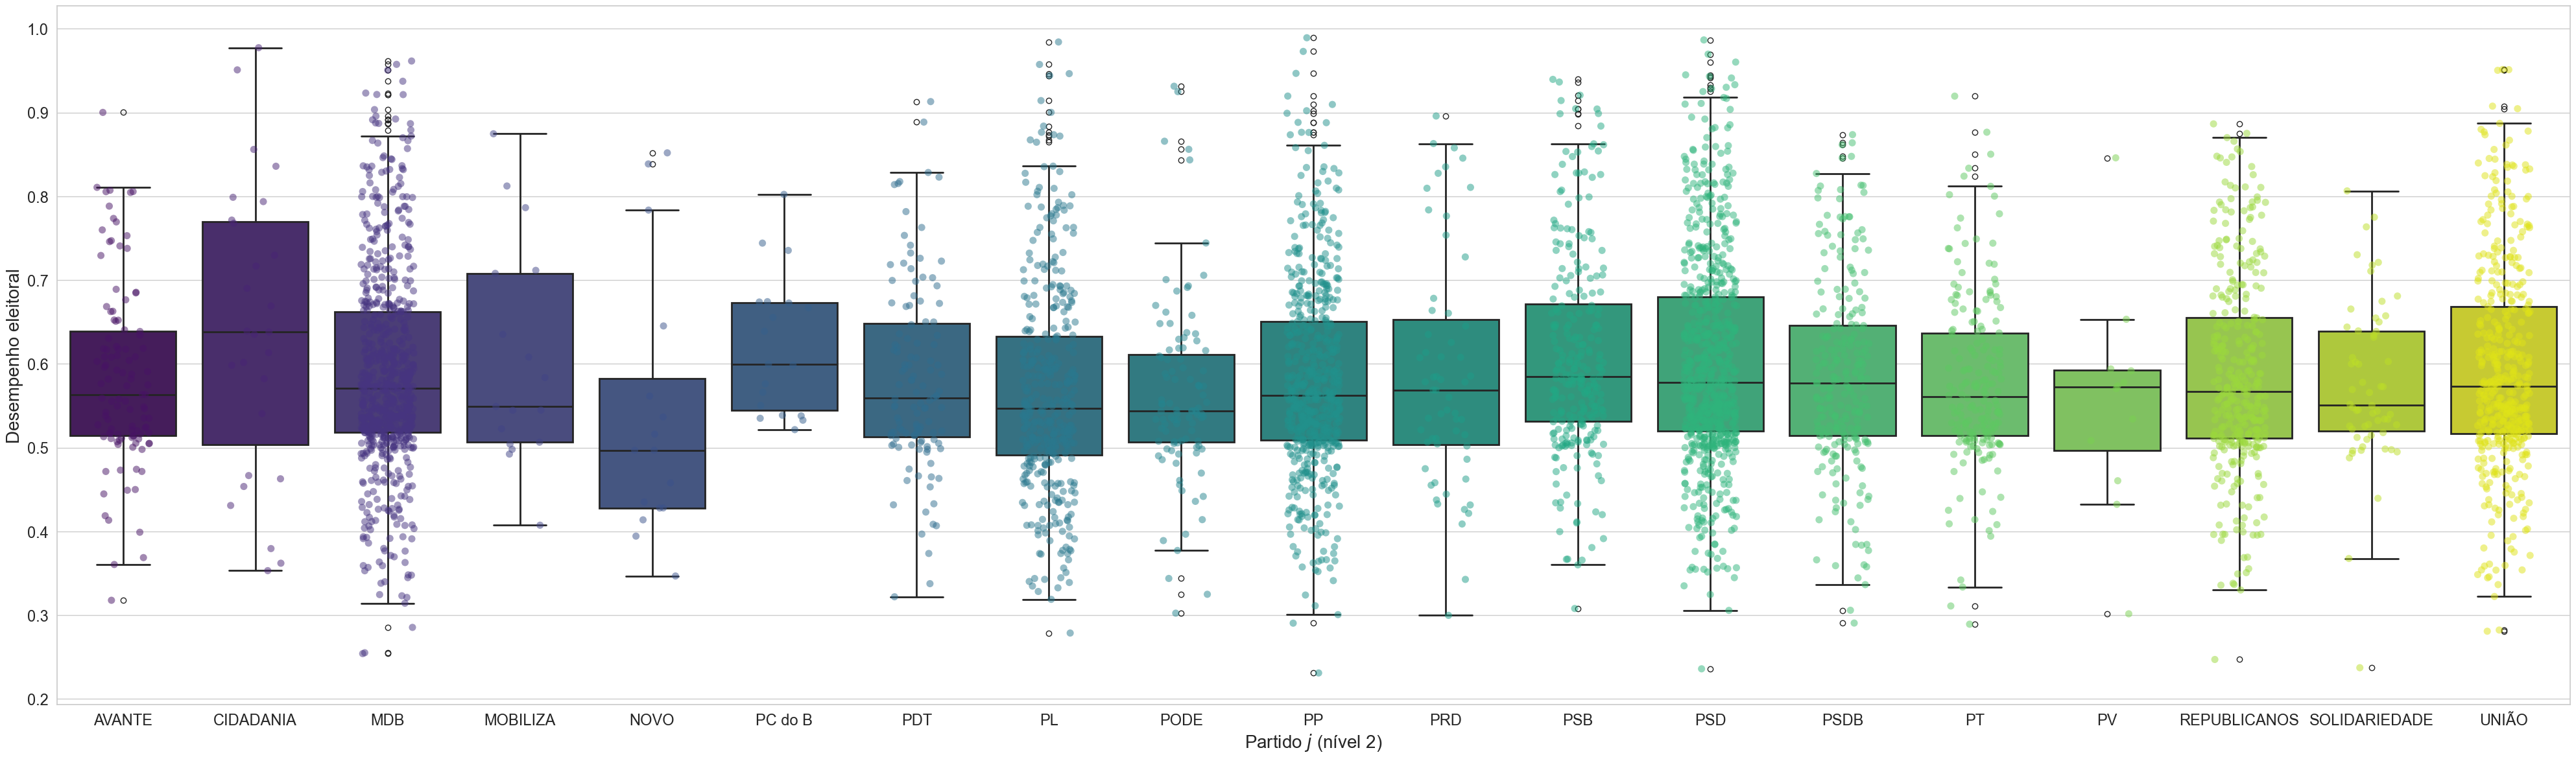

In [13]:
plt.figure(figsize=(50,14))
sns.boxplot(data=df, x='sigla_partido_prefeito_eleito', y='porcentagem_votos_validos_2024',
            linewidth=2, orient='v', palette='viridis')
sns.stripplot(data=df, x='sigla_partido_prefeito_eleito', y='porcentagem_votos_validos_2024',
              palette='viridis', jitter=0.2, size=8, alpha=0.5)
plt.ylabel('Desempenho eleitoral', fontsize=20)
plt.xlabel('Partido $j$ (nível 2)', fontsize=20)
plt.tick_params(axis='y', labelsize=17)
plt.tick_params(axis='x', labelsize=17)
plt.show()


## Kernel density estimation (KDE) - função densidade de probabilidade

<Figure size 1500x1000 with 0 Axes>

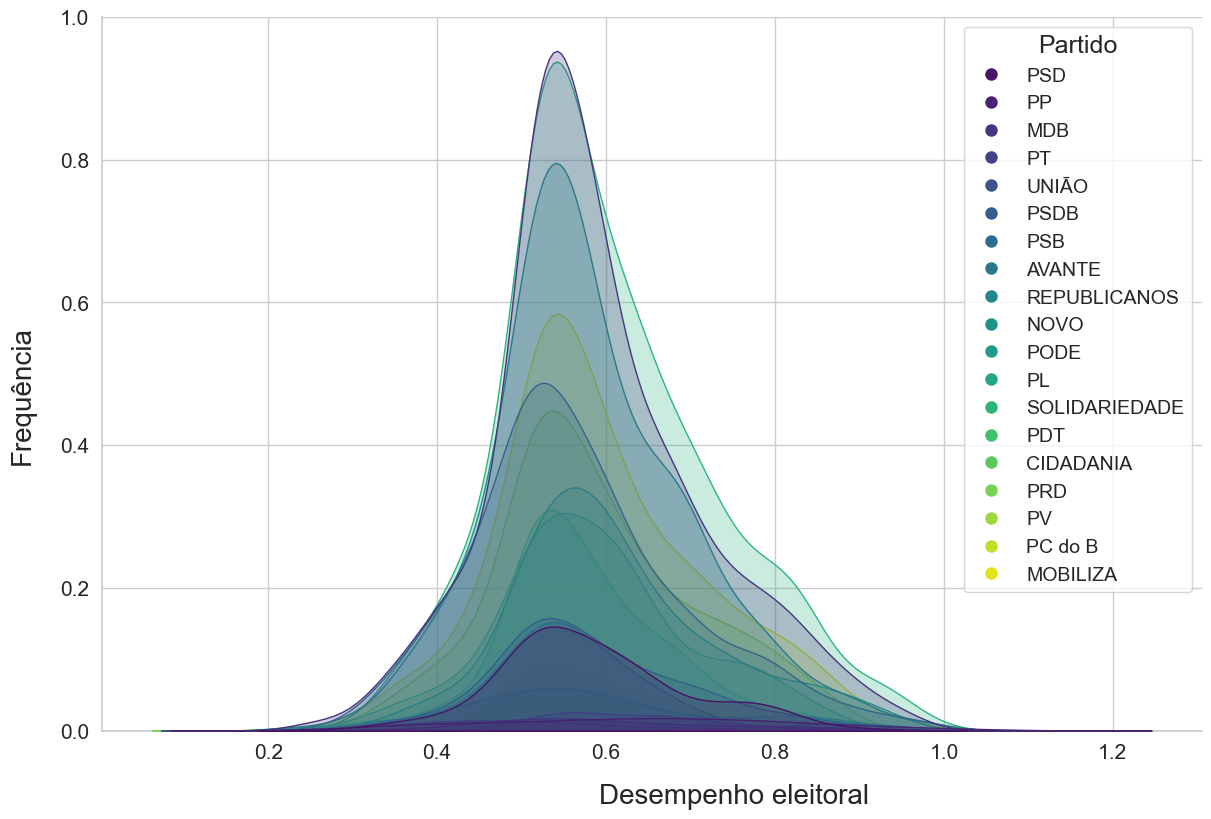

In [14]:
#da variável dependente ('desempenho') por sigla_partido_prefeito_eleito

partidos = df['sigla_partido_prefeito_eleito'].unique()
colors = sns.color_palette('viridis', len(partidos))

plt.figure(figsize=(15, 10))
g = sns.pairplot(df[['sigla_partido_prefeito_eleito', 'porcentagem_votos_validos_2024']], hue='sigla_partido_prefeito_eleito',
                 height=8,
                 aspect=1.5, palette=colors)
g._legend.remove()
g.set(xlabel=None)
g.set(ylabel=None)
g.tick_params(axis='both', which='major', labelsize=15)

# Gera a legenda com cores e rótulos das municipios
legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=color,
                              markersize=10, label=sigla_partido_prefeito_eleito)
                   for sigla_partido_prefeito_eleito, color in zip(partidos, colors)]
plt.legend(handles=legend_elements, title='Partido', fontsize=14,
           title_fontsize=18)

# Adiciona os rótulos diretamente na figura
plt.gcf().text(0.5, -0.01, 'Desempenho eleitoral', ha='center', fontsize=20)
plt.gcf().text(-0.01, 0.5, 'Frequência', va='center', rotation='vertical',
               fontsize=20)
plt.show()



## Kernel density estimation (KDE) - função densidade de probabilidade**

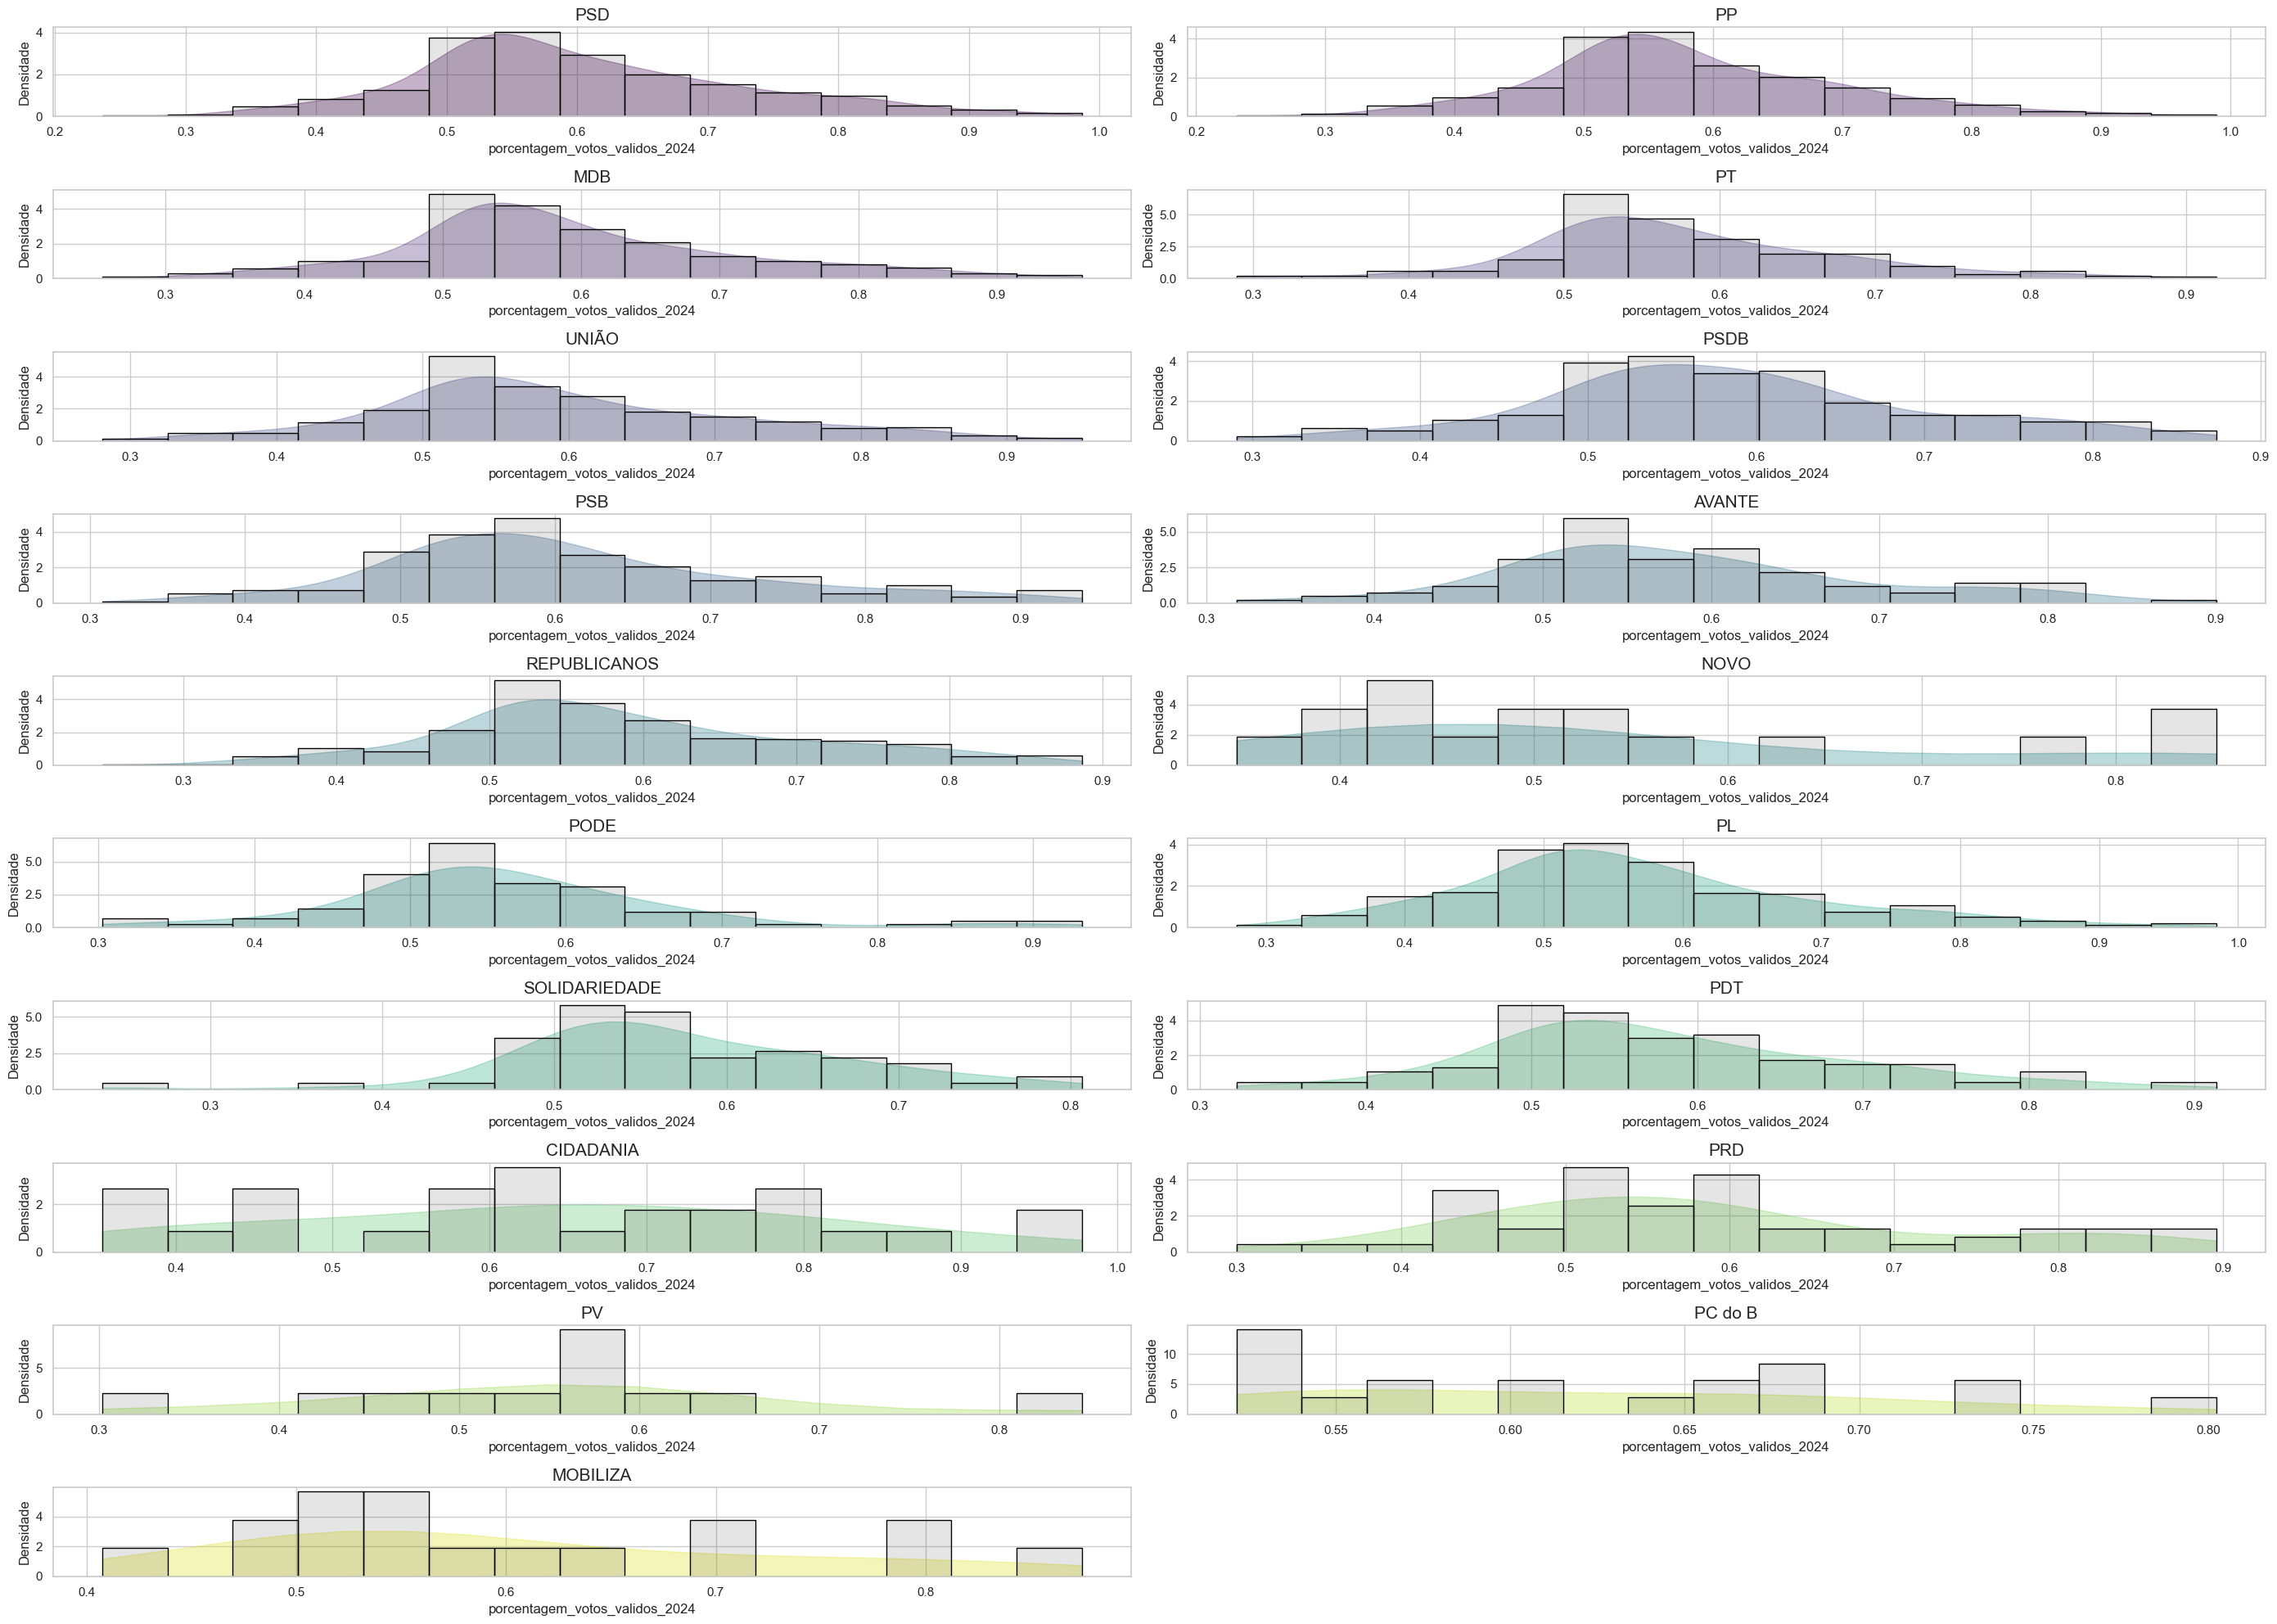

In [15]:

#da variável dependente ('porcentagem_votos_validos_2024'), com histograma e por sigla_partido_prefeito_eleito separadamente
#(função 'GridSpec' do pacote 'matplotlib.gridspec')

partidos = df['sigla_partido_prefeito_eleito'].unique()

fig = plt.figure(figsize=(28, 20))
gs = GridSpec(len(partidos) // 2 + 1, 2, figure=fig)

for i, sigla_partido_prefeito_eleito in enumerate(partidos):
    ax = fig.add_subplot(gs[i])

    # Subset dos dados por sigla_partido_prefeito_eleito
    df_escola = df[df['sigla_partido_prefeito_eleito'] == sigla_partido_prefeito_eleito]

    # Densidade dos dados
    densidade = gaussian_kde(df_escola['porcentagem_votos_validos_2024'])
    x_vals = np.linspace(min(df_escola['porcentagem_votos_validos_2024']),
                         max(df_escola['porcentagem_votos_validos_2024']), len(df_escola))
    y_vals = densidade(x_vals)

    # Plotagem da density area
    ax.fill_between(x_vals, y_vals,
                    color=sns.color_palette('viridis',
                                            as_cmap=True)(i/len(partidos)),
                    alpha=0.3)
    
    # Adiciona o histograma
    sns.histplot(df_escola['porcentagem_votos_validos_2024'], ax=ax, stat="density", color="black",
                 edgecolor="black", fill=True, 
                 bins=15, alpha=0.1)
    ax.set_title(f'{sigla_partido_prefeito_eleito}', fontsize=15)
    ax.set_ylabel('Densidade')
    ax.set_xlabel('porcentagem_votos_validos_2024')

plt.tight_layout()
plt.show()



## Gráfico de desempenho eleitoral x emendas_pix (OLS)

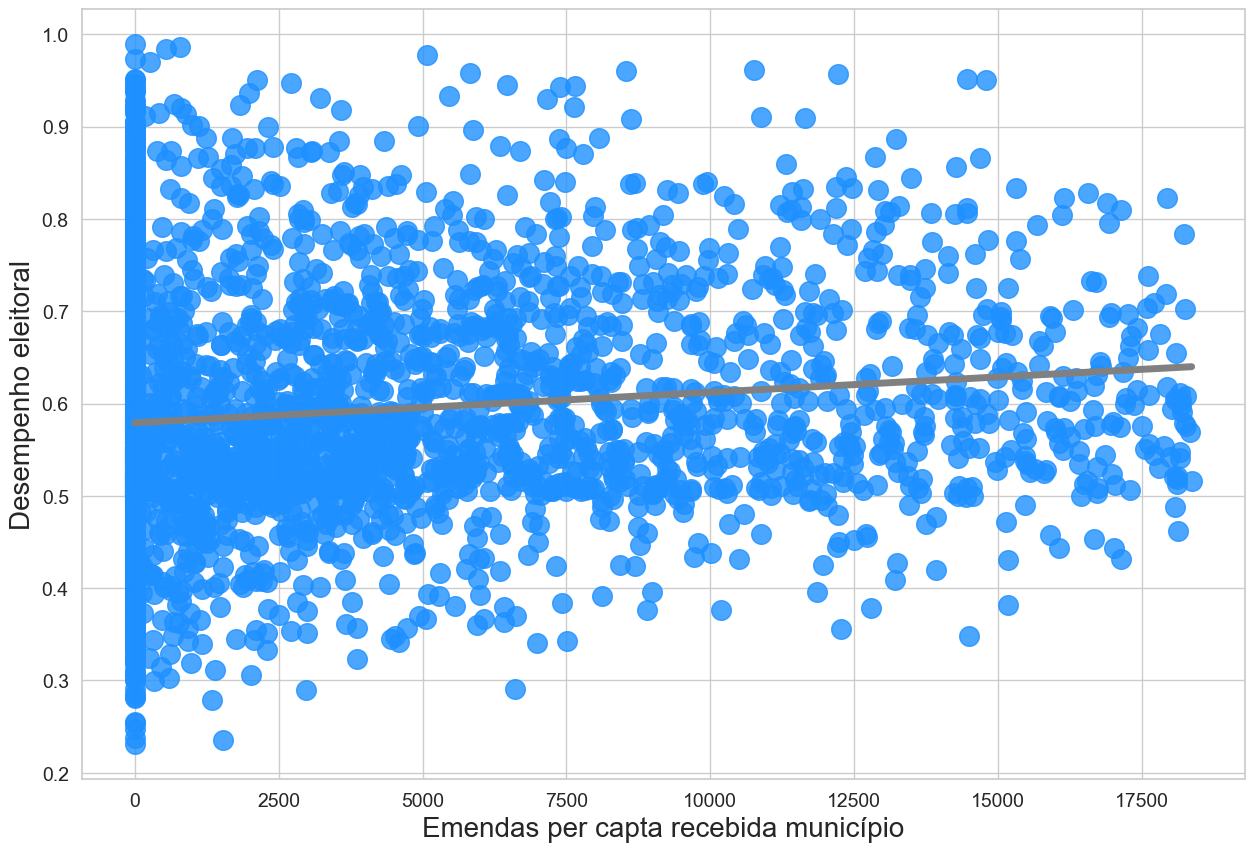

In [16]:
plt.figure(figsize=(15,10))
sns.regplot(
    data=df,
    x='emendas_pix_per_capita_partido_prefeito_eleito',
    y='porcentagem_votos_validos_2024',
    marker='o',
    ci=False,
    scatter_kws={"color": 'dodgerblue', "alpha": 0.8, "s": 200},
    line_kws={"color": 'grey', "linewidth": 5}
)

# switch to log scale on the x-axis
plt.xscale('linear')

plt.xlabel('Emendas per capta recebida município', fontsize=20)
plt.ylabel('Desempenho eleitoral', fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

## Gráfico de desempenho x emendas_pix (OLS) por partido separadamente



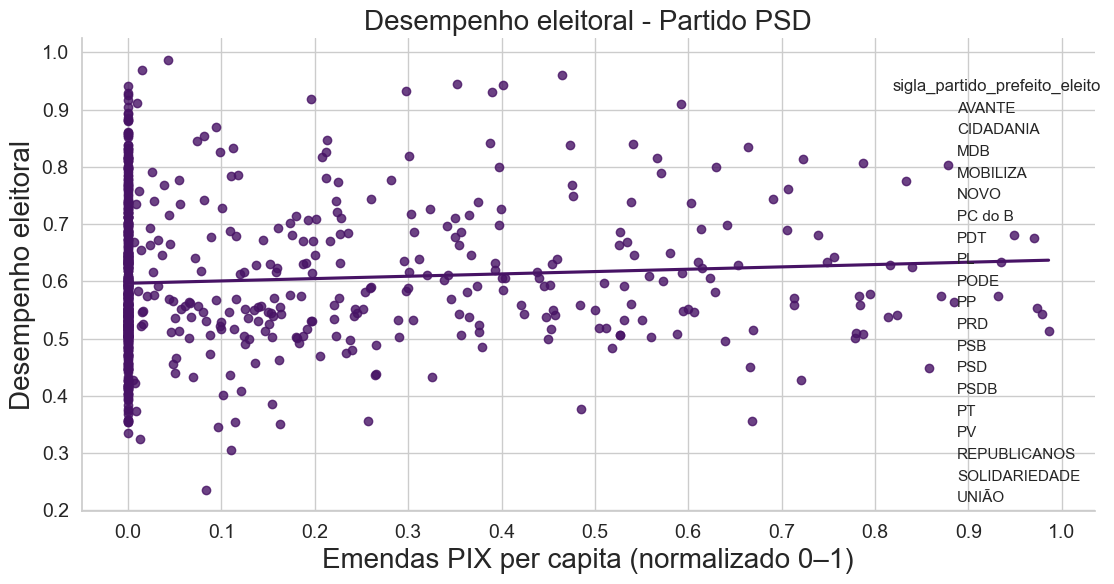

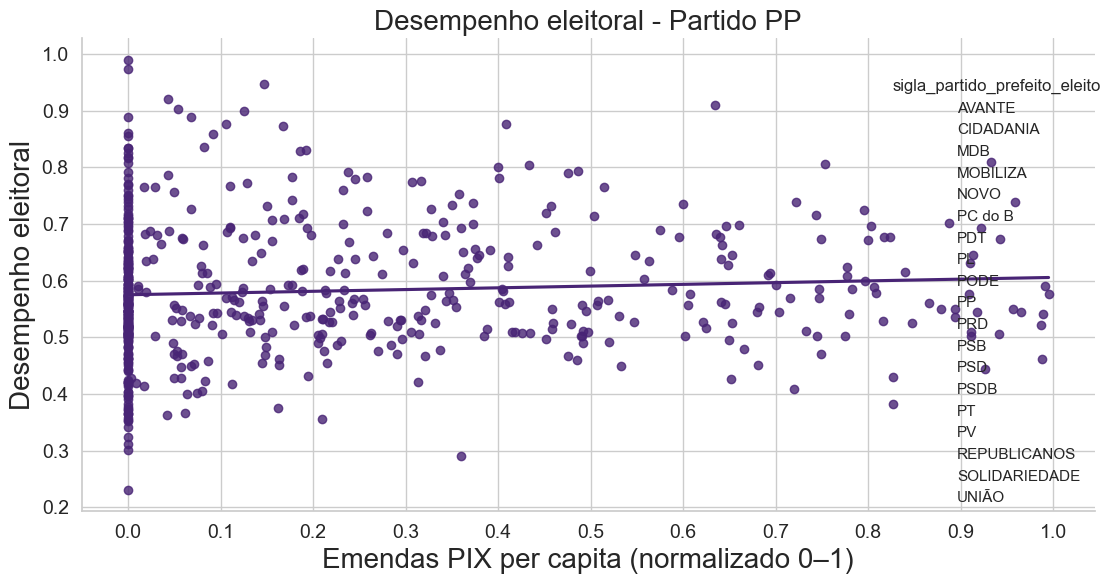

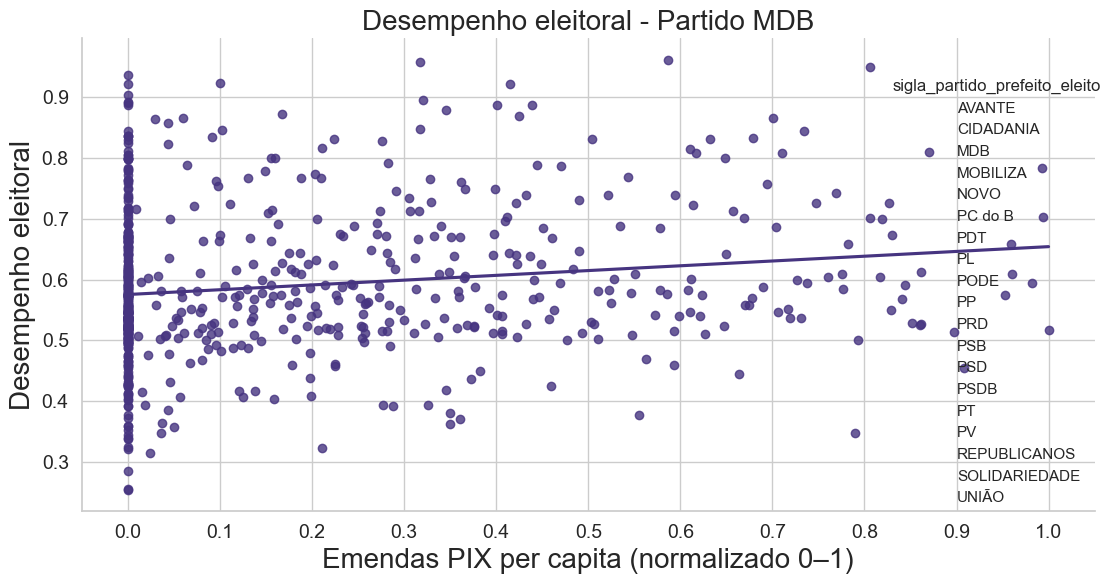

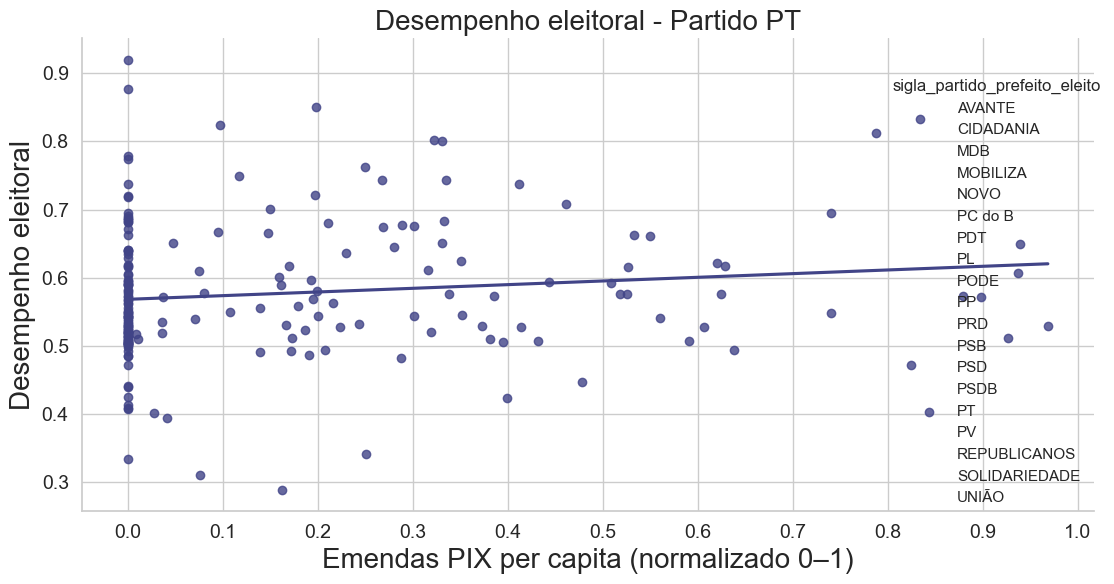

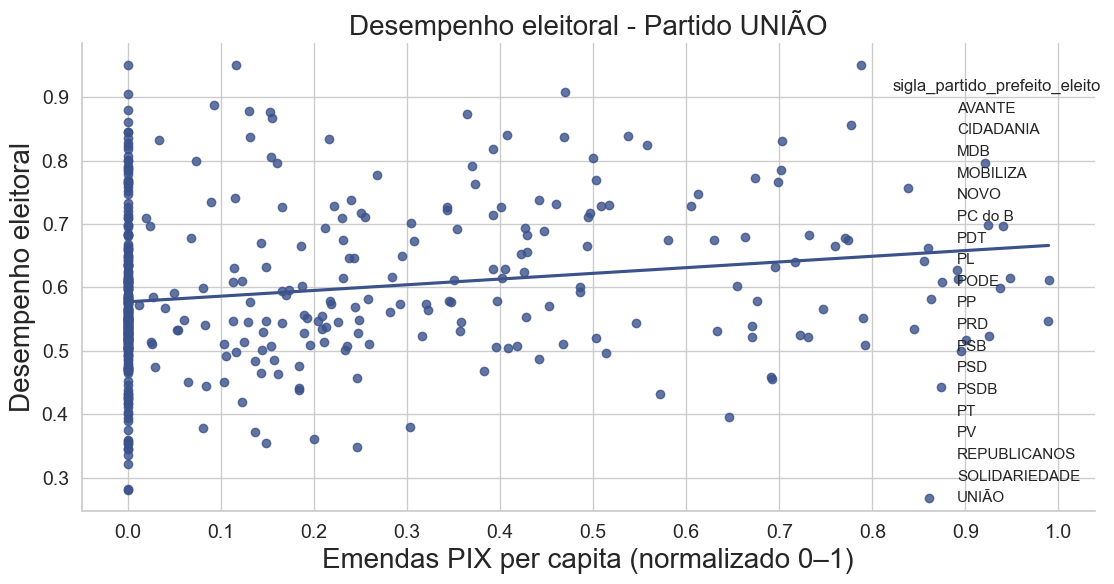

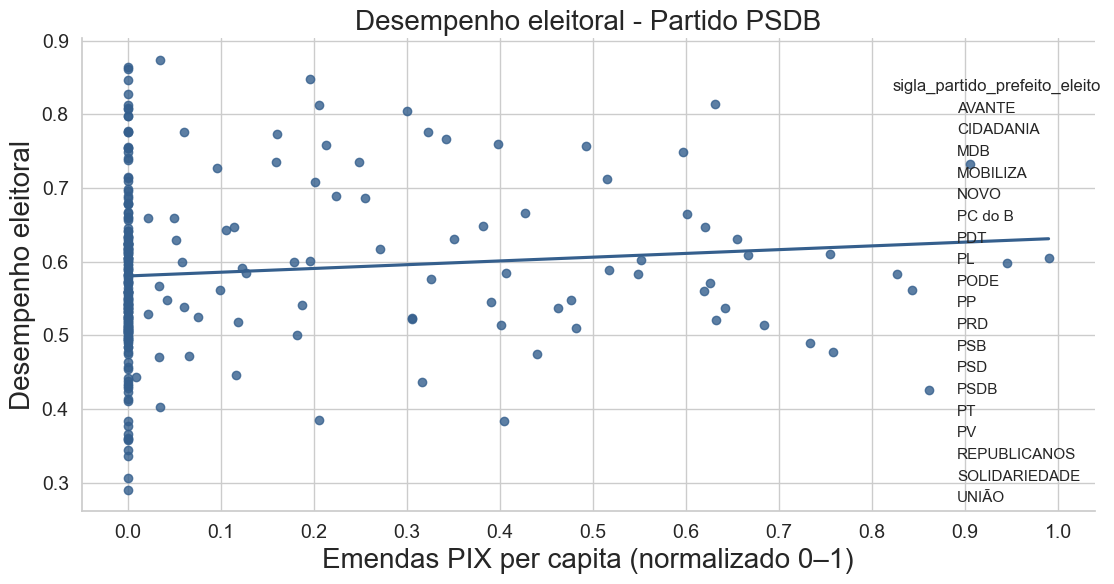

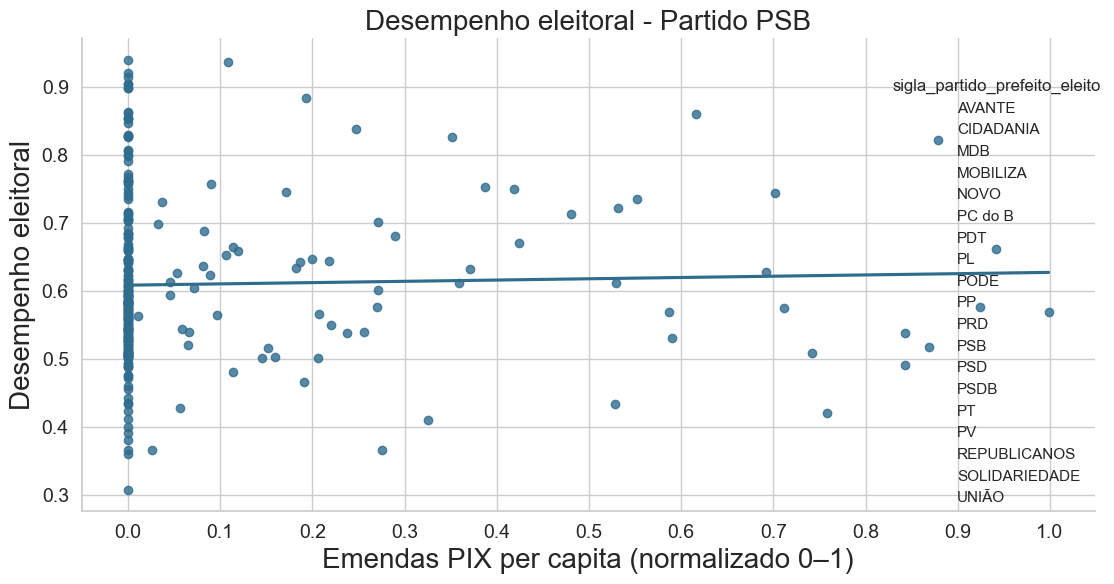

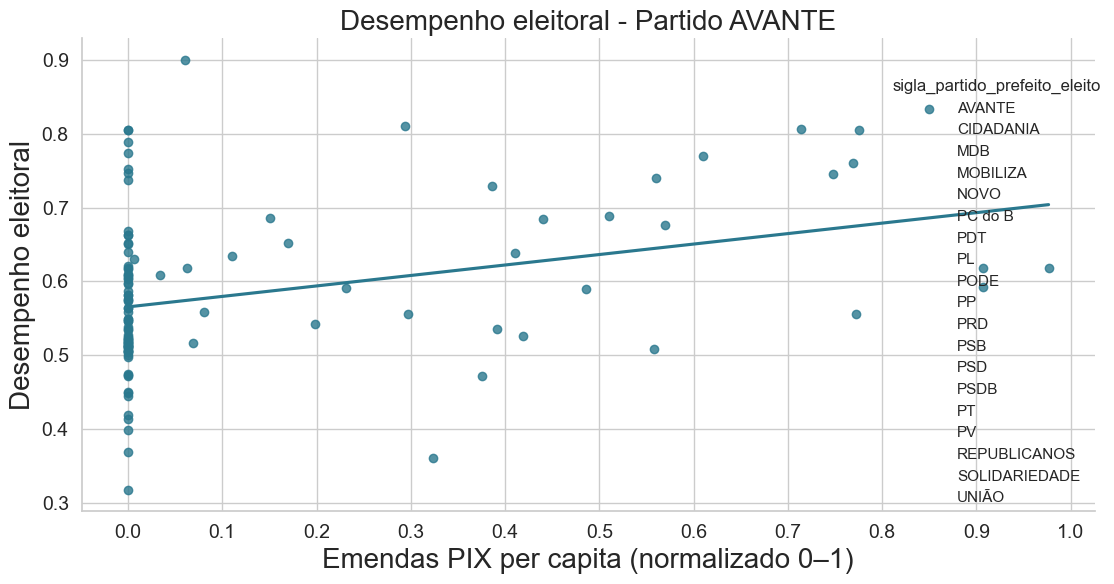

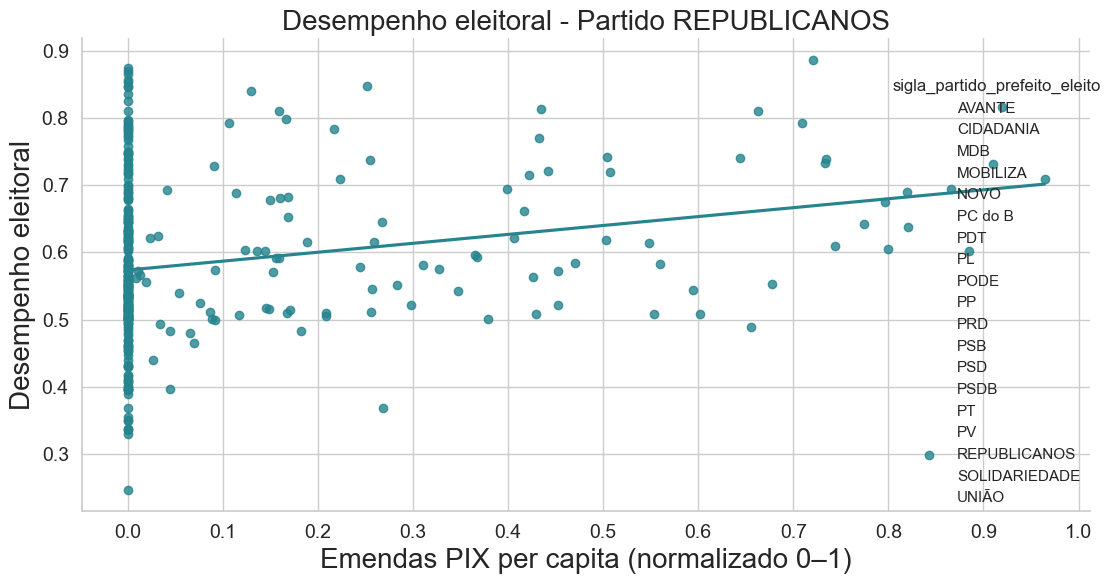

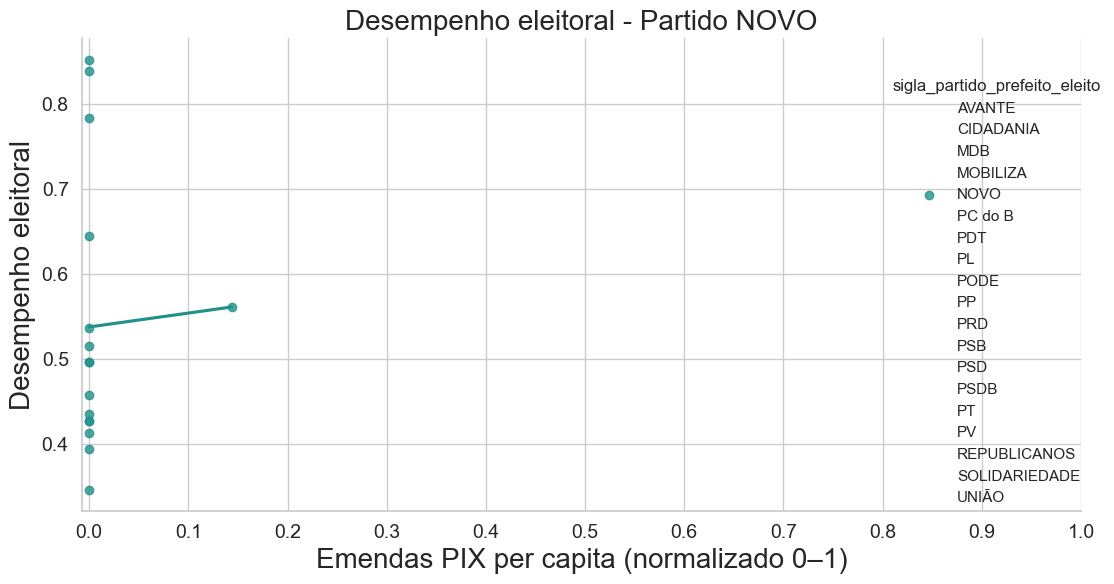

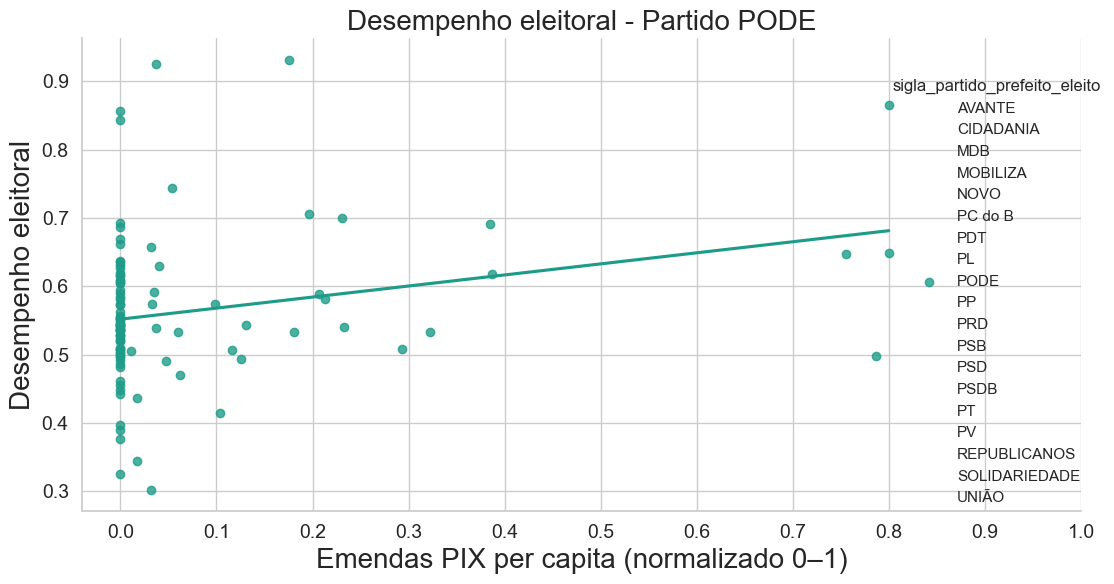

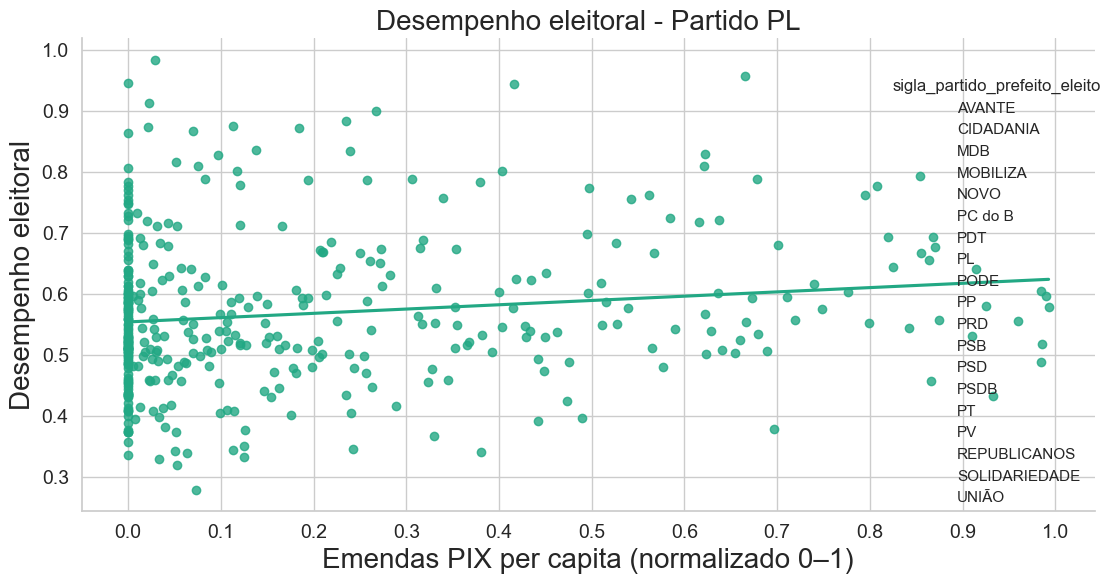

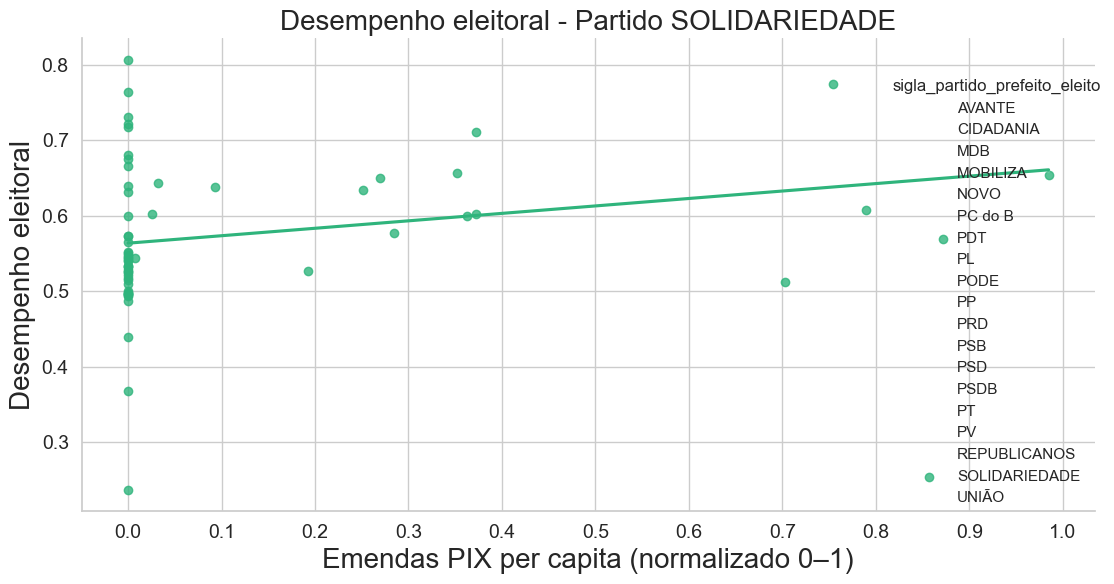

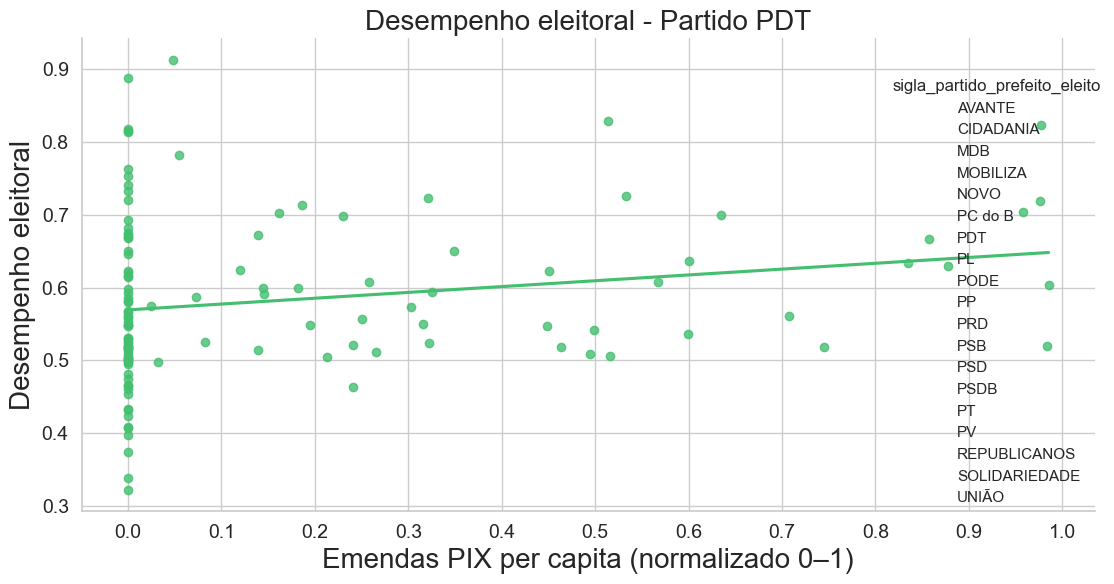

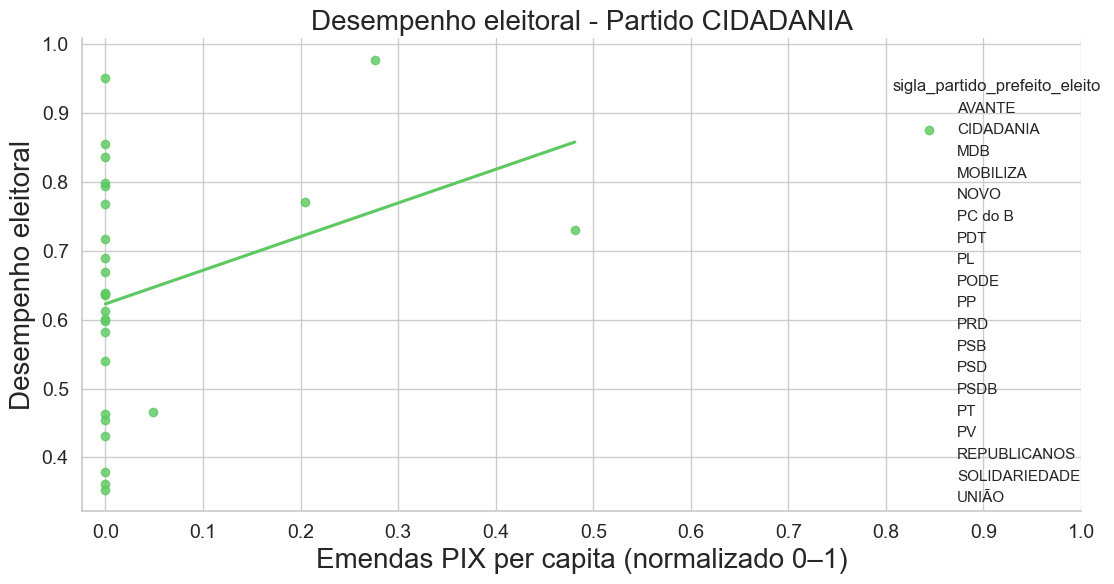

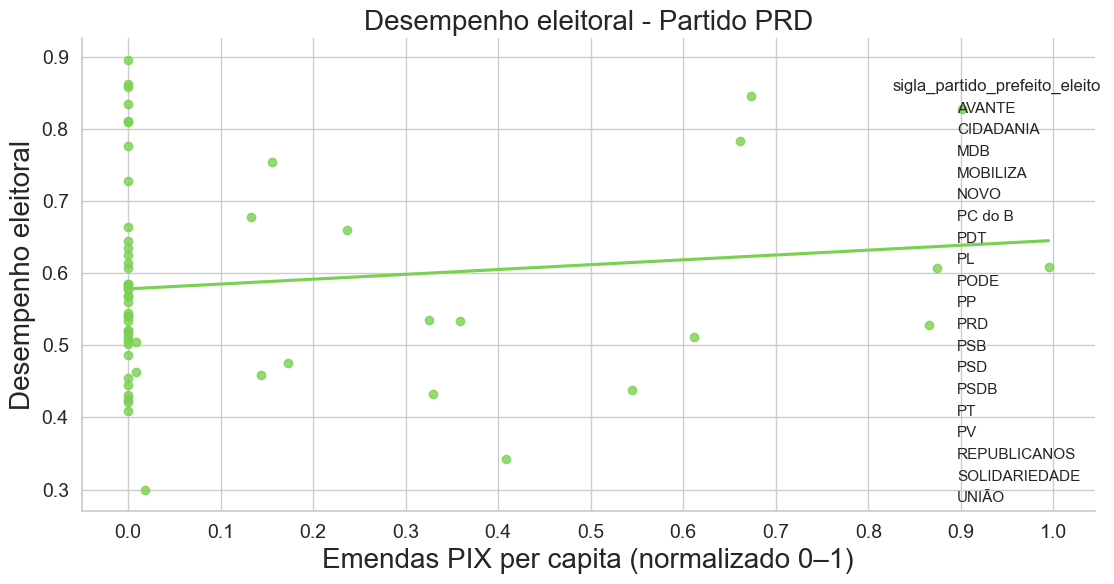

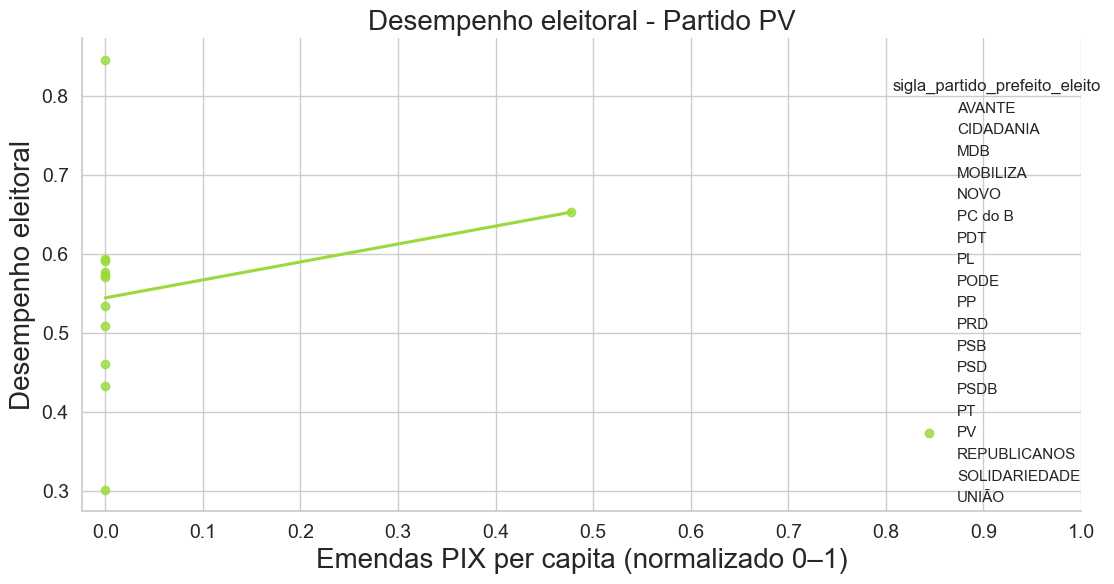

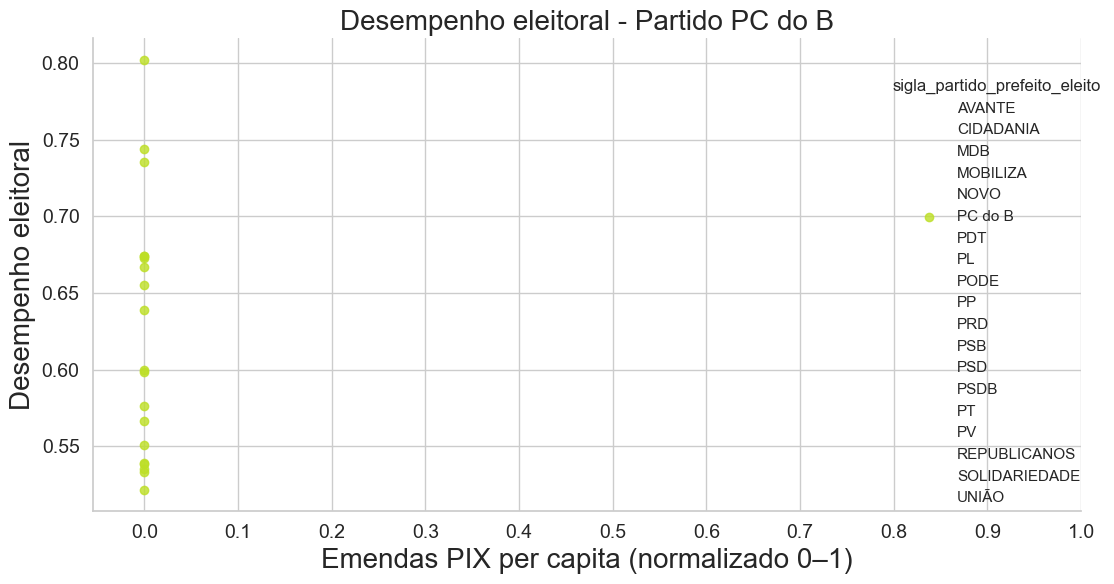

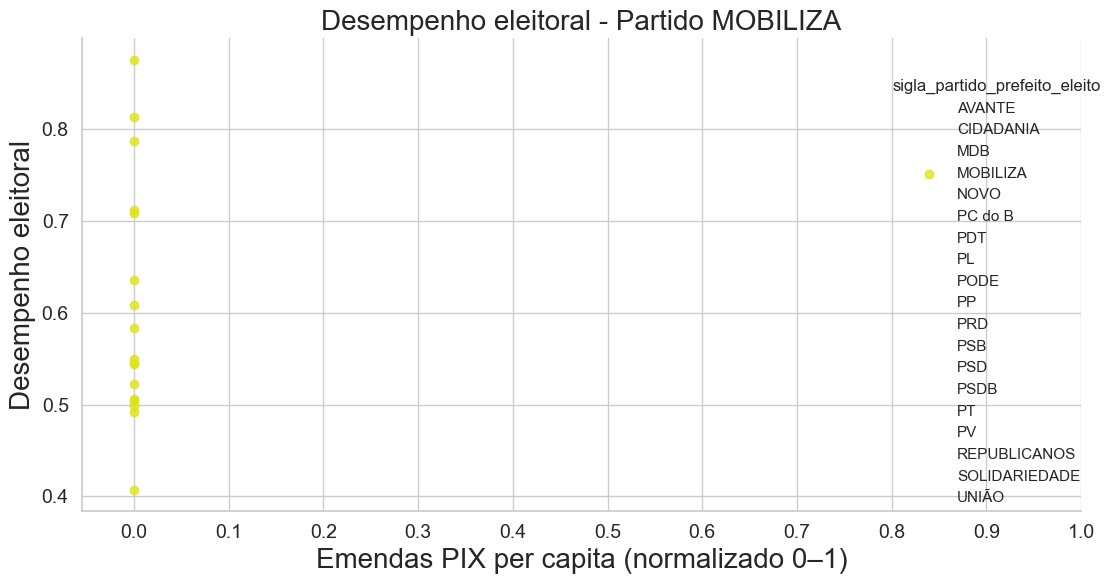

In [17]:
# Normalização min–max da coluna de emendas (toda a base de uma vez)
min_em = df['emendas_pix_per_capita_partido_prefeito_eleito'].min()
max_em = df['emendas_pix_per_capita_partido_prefeito_eleito'].max()
df['emendas_norm'] = (
    df['emendas_pix_per_capita_partido_prefeito_eleito'] - min_em
) / (max_em - min_em)

# Obtenção da lista de partidos
partidos = df['sigla_partido_prefeito_eleito'].unique()

# Definição do número de cores na paleta viridis
num_cores = len(partidos)
cor_escola = dict(zip(partidos, sns.color_palette('viridis', num_cores)))


for partido in partidos:
    data = df[df['sigla_partido_prefeito_eleito'] == partido]

    # lmplot retornando FacetGrid
    g = sns.lmplot(
        x='emendas_norm',
        y='porcentagem_votos_validos_2024',
        data=data,
        hue='sigla_partido_prefeito_eleito',
        height=6,
        aspect=1.5,
        ci=False,
        palette=[cor_escola[partido]]
    )

    # Títulos e rótulos
    g.set_xlabels("Emendas PIX per capita (normalizado 0–1)", fontsize=20)
    g.set_ylabels("Desempenho eleitoral", fontsize=20)
    plt.title(f"Desempenho eleitoral - Partido {partido}", fontsize=20)

    # Ajuste de ticks na escala 0–1
    xticks = np.linspace(0, 1, 11)
    g.ax.set_xticks(xticks)
    g.ax.set_xticklabels([f"{x:.1f}" for x in xticks], fontsize=14)
    g.ax.tick_params(axis='y', labelsize=14)

    plt.tight_layout()
    plt.show()

    time.sleep(1)

## Gráfico de desempenho eleitoral em função da variável emendas_pix_per_capta

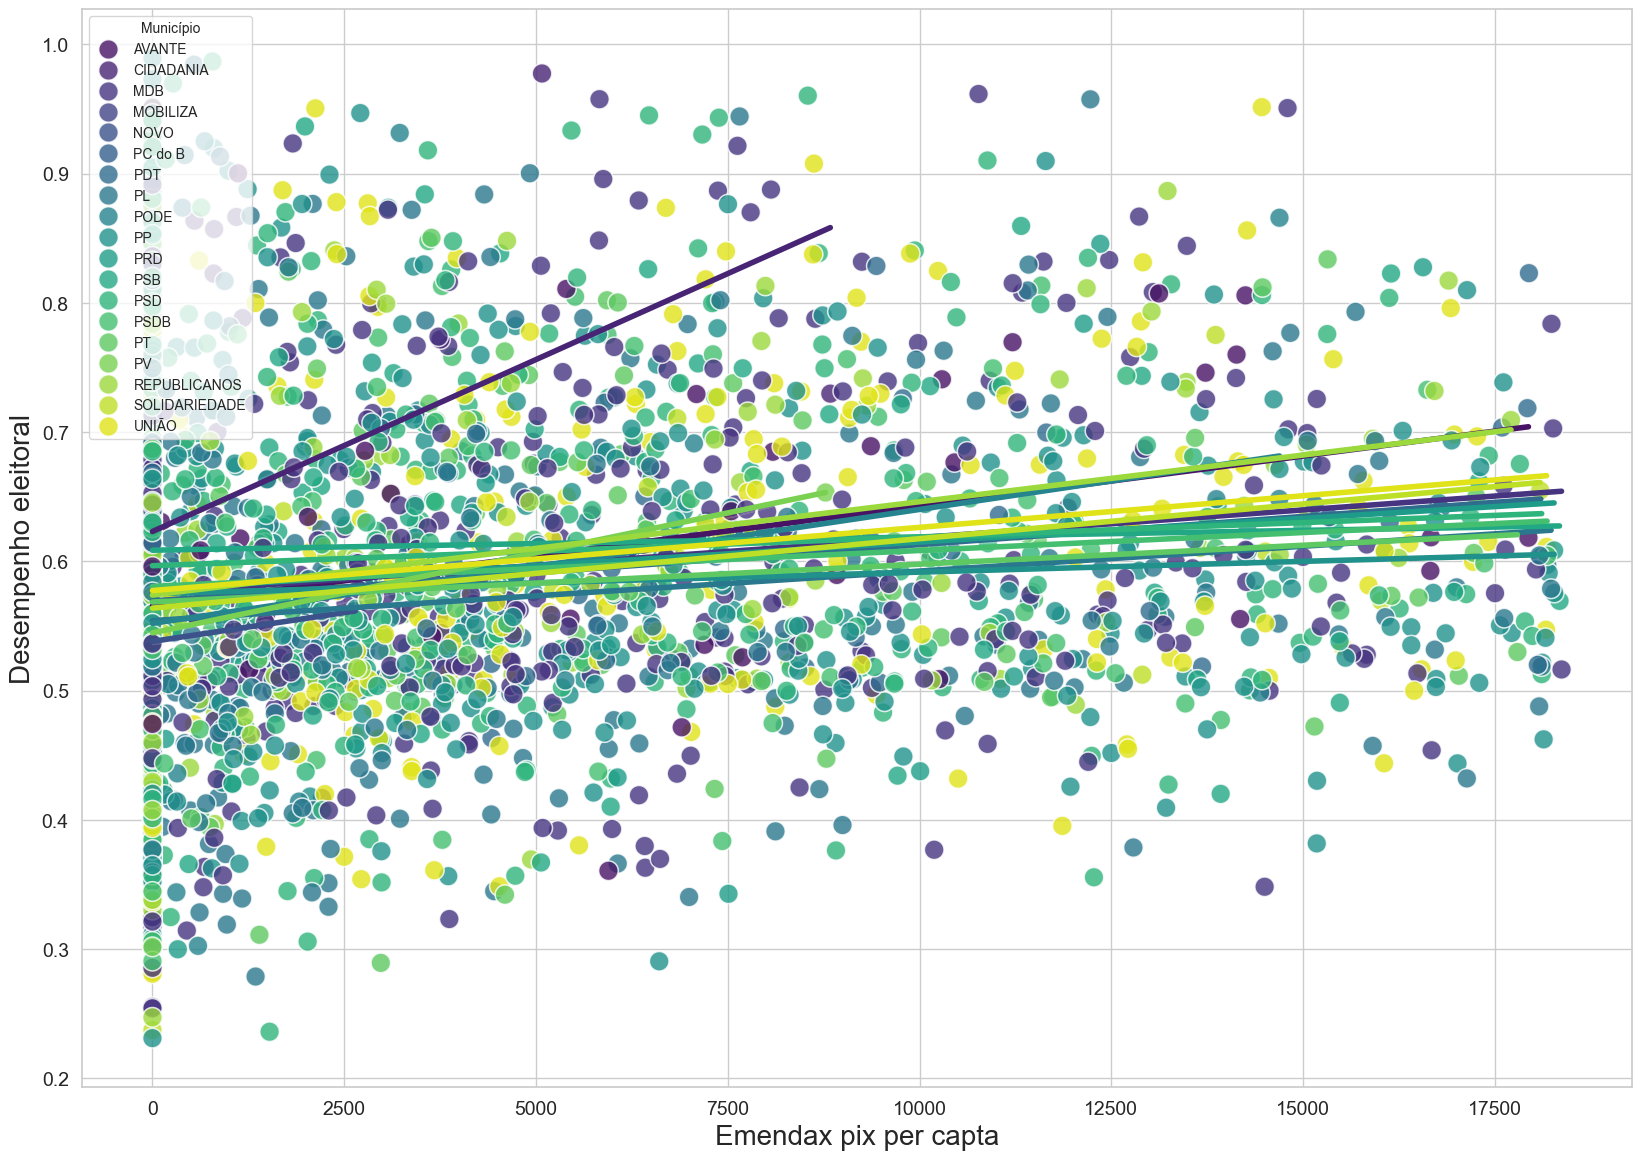

In [18]:

# Variação entre estudantes de uma mesma escola e entre escolas diferentes
# Visualização do contexto!
# NOTE QUE A PERSPECTIVA MULTINÍVEL NATURALMENTE CONSIDERA O COMPORTAMENTO
#HETEROCEDÁSTICO NOS DADOS!

palette = sns.color_palette('viridis',
                            len(df['sigla_partido_prefeito_eleito'].unique()))

plt.figure(figsize=(20,14))
sns.scatterplot(data=df, x='emendas_pix_per_capita_partido_prefeito_eleito', y='porcentagem_votos_validos_2024', hue='sigla_partido_prefeito_eleito',
                palette=palette, s=200, alpha=0.8, edgecolor='w')

for partido in df['sigla_partido_prefeito_eleito'].cat.categories:
    subset = df[df['sigla_partido_prefeito_eleito'] == partido]
    sns.regplot(data=subset, x='emendas_pix_per_capita_partido_prefeito_eleito', y='porcentagem_votos_validos_2024', scatter=False, ci=False,
                line_kws={"color": palette[df['sigla_partido_prefeito_eleito'].cat.categories.get_loc(partido)], 'linewidth': 4})

plt.xlabel('Emendax pix per capta', fontsize=20)
plt.ylabel('Desempenho eleitoral', fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(title='Município', title_fontsize='10', fontsize='10', loc='upper left')
plt.show()



In [19]:

##############################################################################
#                        ESTIMAÇÃO DO MODELO NULO HLM2                       #
##############################################################################

# Estimação do modelo nulo (função 'MixedLM' do pacote 'statsmodels')

modelo_nulo_hlm2 = sm.MixedLM.from_formula(formula='porcentagem_votos_validos_2024 ~ 1',
                                           groups='sigla_partido_prefeito_eleito',
                                           re_formula='1',
                                           data=df).fit()

# Parâmetros do 'modelo_nulo_hlm2'
modelo_nulo_hlm2.summary()



e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                   Mixed Linear Model Regression Results
============================================================================
Model:            MixedLM Dependent Variable: porcentagem_votos_validos_2024
No. Observations: 4385    Method:             REML                          
No. Groups:       19      Scale:              0.0144                        
Min. group size:  12      Log-Likelihood:     3058.9304                     
Max. group size:  727     Converged:          Yes                           
Mean group size:  230.8                                                     
----------------------------------------------------------------------------
                                  Coef. Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                         0.587    0.003 169.938 0.000  0.580  0.594
sigla_partido_prefeito_eleito Var 0.000    0.001                            
============================================================================

"""

In [20]:
import statsmodels.formula.api as smf

In [21]:
# Modelo nulo
null_model = smf.mixedlm(
    'porcentagem_votos_validos_2024 ~ 1',
    df,
    groups=df['sigla_partido_prefeito_eleito'],
    vc_formula={'estado': '0 + C(sigla_municipio)'}
)
null_res = null_model.fit()
print(null_res.summary())


                   Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: porcentagem_votos_validos_2024
No. Observations: 4385    Method:             REML                          
No. Groups:       19      Scale:              0.0139                        
Min. group size:  12      Log-Likelihood:     3089.2752                     
Max. group size:  727     Converged:          Yes                           
Mean group size:  230.8                                                     
--------------------------------------------------------------------------------
                  Coef.     Std.Err.        z        P>|z|     [0.025     0.975]
--------------------------------------------------------------------------------
Intercept         0.586        0.003     204.848     0.000      0.580      0.591
estado Var        0.001        0.001                                            



e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [22]:

#intercepto

teste = float(modelo_nulo_hlm2.cov_re.iloc[0, 0]) /\
    float(pd.DataFrame(modelo_nulo_hlm2.summary().tables[1]).iloc[1, 1])

p_value = 2 * (1 - stats.norm.cdf(abs(teste)))

print(f"Estatística z para a Significância dos Efeitos Aleatórios: {teste:.3f}")
print(f"P-valor: {p_value:.3f}")

if p_value >= 0.05:
    print("Ausência de significância estatística dos efeitos aleatórios ao nível de confiança de 95%.")
else:
    print("Efeitos aleatórios contextuais significantes ao nível de confiança de 95%.")


Estatística z para a Significância dos Efeitos Aleatórios: 0.110
P-valor: 0.912
Ausência de significância estatística dos efeitos aleatórios ao nível de confiança de 95%.


In [23]:

##############################################################################
#                   COMPARAÇÃO DO HLM2 NULO COM UM OLS NULO                  #
##############################################################################

# Estimação de um modelo OLS nulo

modelo_ols_nulo = sm.OLS.from_formula(formula='porcentagem_votos_validos_2024 ~ 1',
                                      data=df).fit()

# Parâmetros do 'modelo_ols_nulo'
modelo_ols_nulo.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                  
==========================================================================================
Dep. Variable:     porcentagem_votos_validos_2024   R-squared:                       0.000
Model:                                        OLS   Adj. R-squared:                  0.000
Method:                             Least Squares   F-statistic:                       nan
Date:                            Tue, 17 Jun 2025   Prob (F-statistic):                nan
Time:                                    21:51:41   Log-Likelihood:                 3057.1
No. Observations:                            4385   AIC:                            -6112.
Df Residuals:                                4384   BIC:                            -6106.
Df Model:                                       0                                         
Covariance Type:                        nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5885      0.002    323.355      0.000       0.585       0.592
==============================================================================
Omnibus:                      186.764   Durbin-Watson:                   2.012
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              211.260
Skew:                           0.514   Prob(JB):                     1.33e-46
Kurtosis:                       3.312   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

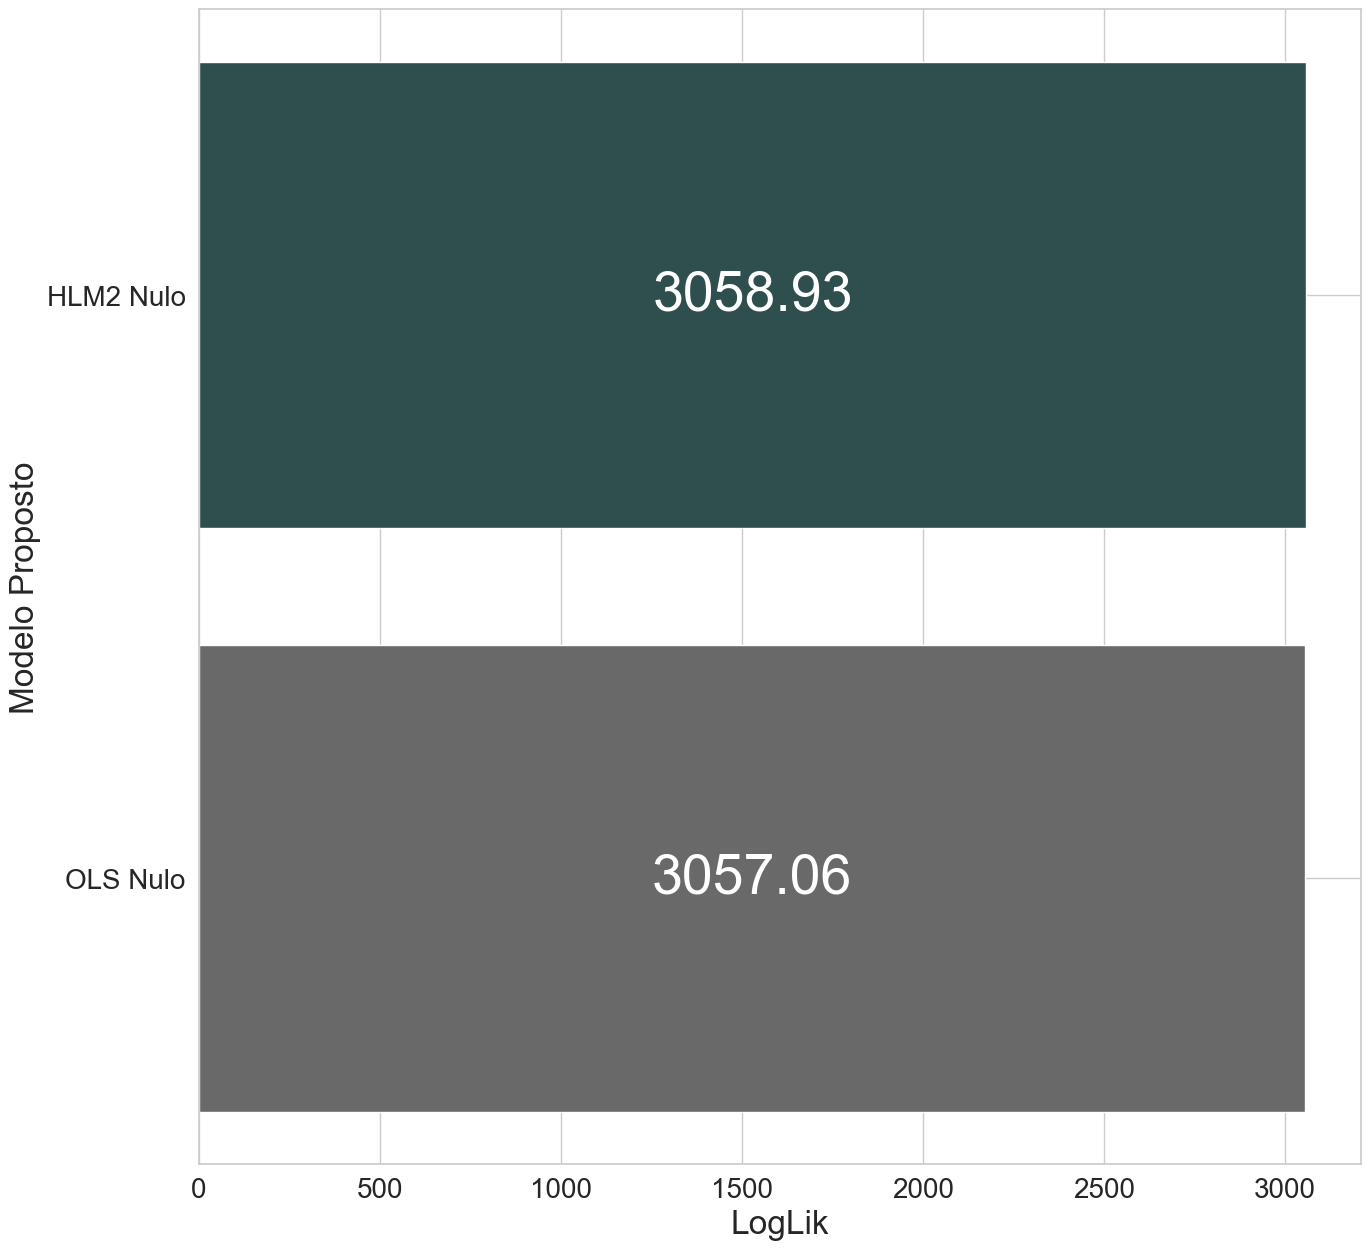

In [24]:

#até o momento

df_llf = pd.DataFrame({'modelo':['OLS Nulo','HLM2 Nulo'],
                      'loglik':[modelo_ols_nulo.llf,modelo_nulo_hlm2.llf]})

fig, ax = plt.subplots(figsize=(15,15))

c = ['dimgray','darkslategray']

ax1 = ax.barh(df_llf.modelo,df_llf.loglik, color = c)
ax.bar_label(ax1, label_type='center', color='white', fontsize=40)
ax.set_ylabel("Modelo Proposto", fontsize=24)
ax.set_xlabel("LogLik", fontsize=24)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)
plt.show()



In [25]:

#'modelo_ols_nulo'

def lrtest(modelos):
    modelo_1 = modelos[0]
    llk_1 = modelo_1.llf
    llk_2 = modelo_1.llf
    
    if len(modelos)>1:
        llk_1 = modelo_1.llf
        llk_2 = modelos[1].llf
    LR_statistic = -2*(llk_1-llk_2)
    p_val = stats.chi2.sf(LR_statistic, 1) # 1 grau de liberdade
    
    print("Likelihood Ratio Test:")
    print(f"-2.(LL0-LLm): {round(LR_statistic, 2)}")
    print(f"p-value: {p_val:.3f}")
    print("")
    print("==================Result======================== \n")
    if p_val <= 0.05:
        print("H1: Different models, favoring the one with the highest Log-Likelihood")
    else:
        print("H0: Models with log-likelihoods that are not statistically different at 95% confidence level")



In [26]:

#dos 'modelo_ols_nulo' e 'modelo_nulo_hlm2'

lrtest([modelo_ols_nulo, modelo_nulo_hlm2])



Likelihood Ratio Test:
-2.(LL0-LLm): 3.73
p-value: 0.053

==================Result======================== 

H0: Models with log-likelihoods that are not statistically different at 95% confidence level


In [27]:

##############################################################################
#     ESTIMAÇÃO DO MODELO COM INTERCEPTOS E INCLINAÇÕES ALEATÓRIOS HLM2      #
##############################################################################

# Estimação do modelo com interceptos e inclinações aleatórios

modelo_intercept_inclin_hlm2 = sm.MixedLM.from_formula(formula='porcentagem_votos_validos_2024 ~ emendas_pix_per_capita_partido_prefeito_eleito',
                                                       groups='sigla_partido_prefeito_eleito',
                                                       re_formula='emendas_pix_per_capita_partido_prefeito_eleito',
                                                       data=df).fit()

# Parâmetros do 'modelo_intercept_inclin_hlm2'
modelo_intercept_inclin_hlm2.summary()



e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
e:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood opti

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                           Mixed Linear Model Regression Results
============================================================================================================================
Model:                            MixedLM                 Dependent Variable:                 porcentagem_votos_validos_2024
No. Observations:                 4385                    Method:                             REML                          
No. Groups:                       19                      Scale:                              0.0140                        
Min. group size:                  12                      Log-Likelihood:                     2940.8851                     
Max. group size:                  727                     Converged:                          No                            
Mean group size:                  230.8                                                                                     
----------------------------------------------------------------------------------------------------------------------------
                                                                                   Coef. Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------------------------------------------
Intercept                                                                          0.577    0.009 61.966 0.000  0.559  0.596
emendas_pix_per_capita_partido_prefeito_eleito                                     0.000    0.007  0.001 0.999 -0.014  0.014
sigla_partido_prefeito_eleito Var                                                  0.001                                    
sigla_partido_prefeito_eleito x emendas_pix_per_capita_partido_prefeito_eleito Cov 0.000                                    
emendas_pix_per_capita_partido_prefeito_eleito Var                                 0.001                                    
============================================================================================================================

"""